In [210]:
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [211]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import seaborn as sns   
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from lifelines import CoxPHFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter
from lifelines.statistics import pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts
import warnings
from preproces_prod4_2025_update import *
from scipy.stats import norm
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from matching_case_control import match_nn_max_dist_weigths
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

#### Efectividad de los niños 2024 en el 2025:

In [3]:
df_pf_2025 = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025


In [3]:
df_f_vrs_mrz_ag = pd.read_csv(path_data/'df_f_vrs_mrz_ag.csv')

In [4]:
# df_cox_vrs_duracion, _, df_f_vrs_duracion, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
#                                                         40,
#                                                         group_age=False,
#                                                         weeks_inm=False,
#                                                         fin_inmune=False,
#                                                         cohort='2024',
#                                                         T_inicial = pd.to_datetime('2025-04-01'),
#                                                         fecha_dt = pd.to_datetime('2025-09-30'),
#                                                         duracion_dias_nirse=180, 
#                                                         eliminar_inmunes_pre_season=True,
#                                                         meses_inm_bool=False)

df_cox_vrs_duracion = pd.read_csv(path_data/'df_cox_vrs_duracion.csv')
df_f_vrs_duracion = pd.read_csv(path_data/'df_f_vrs_duracion.csv')

In [5]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs']
T_inicial = pd.to_datetime('2025-04-01')
df_cox = df_cox_vrs_duracion.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inmunizado,-0.181274,-0.513787,0.078201,0.18801,0.166594,0.126544,-0.081428,0.414615


MATCHING NN

In [6]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name']  # ejemplo

df_tv = df_cox_vrs_duracion.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:1 ['1', '1']
here aaa
Total cases = 8156, Total controls = 144216
Total cases matched is : 8156, Total control matched is : 8156
ratio: 1:1
No matched : 0
Iteration 1: norm_delta = 5.85e-02, step_size = 0.9500, log_lik = -90.10913, newton_decrement = 2.46e-01, seconds_since_start = 6.6
Iteration 2: norm_delta = 3.00e-03, step_size = 0.9500, log_lik = -89.86347, newton_decrement = 6.44e-04, seconds_since_start = 13.4
Iteration 3: norm_delta = 1.50e-04, step_size = 0.9500, log_lik = -89.86283, newton_decrement = 1.62e-06, seconds_since_start = 19.7
Iteration 4: norm_delta = 7.92e-06, step_size = 1.0000, log_lik = -89.86282, newton_decrement = 4.06e-09, seconds_since_start = 26.1
Convergence completed after 4 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inmunizado,0.115942,-0.247598,0.37355,0.483176,-0.123233,0.175745,-0.467686,0.22122


#### Covariables de inmmunización a tramos.

In [ ]:
################################################ ESTO ES COMO DEBERÍA SER EL DE ABAJO, PERO NO QUIERO BORRAR LO DE ABAJO PQ EXPLICA EL DATASET QUE TEGNO GUARDADO ###############################################
# 
# df_cox_vrs_tramos_2year, _, df_f_vrs_tramos_2year, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
#                                                         40,
#                                                         group_age=False,
#                                                         weeks_inm=False,
#                                                         fin_inmune=False,
#                                                         cohort='2024',
#                                                         fecha_cohort_in = pd.to_datetime('2023-10-01'),
#                                                         fecha_cohort_out = pd.to_datetime('2025-09-30'),
#                                                         T_inicial = pd.to_datetime('2025-03-01'), 
#                                                         fecha_dt = pd.to_datetime('2025-09-30'),
#                                                         duracion_dias_nirse=180, 
#                                                         eliminar_inmunes_pre_season=False,
#                                                         meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
#                                                         meses_inm_bool=True,
#                                                         ef_2024_in_2025=True)

# df_cox_vrs_tramos_2year_mod = df_cox_vrs_tramos_2year.copy()

# cols = [f"inm_mayor_{k}_meses" for k in range(17)]  # 0..5

# # matriz booleana (trata NaN como 0)
# M = df_cox_vrs_tramos_2year_mod[cols].fillna(0).astype(int).to_numpy().astype(bool)

# # buscar la columna activa de mayor k: invierto columnas y tomo el primer True
# M_rev = M[:, ::-1]
# has_any = M_rev.any(axis=1)
# pos_rev = M_rev.argmax(axis=1)          # índice del primer True en el orden invertido (0..5)
# k_max = (len(cols) - 1) - pos_rev       # convertir a k real (0..5)
# k_max[~has_any] = -1                    # filas sin ningún 1

# # construir la nueva matriz one-hot
# newM = np.zeros_like(M, dtype=int)
# rows = np.arange(M.shape[0])
# mask = k_max >= 0
# newM[rows[mask], k_max[mask]] = 1

# # escribir de vuelta al df (sobrescribe esas columnas)
# df_cox_vrs_tramos_2year_mod.loc[:, cols] = newM


In [7]:
# df_cox_vrs_tramos_2year, _, df_f_vrs_tramos_2year, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
#                                                         40,
#                                                         group_age=False,
#                                                         weeks_inm=False,
#                                                         fin_inmune=False,
#                                                         cohort='2024',
#                                                         T_inicial = pd.to_datetime('2025-03-01'),
#                                                         fecha_dt = pd.to_datetime('2025-08-30'),
#                                                         duracion_dias_nirse=180, 
#                                                         eliminar_inmunes_pre_season=False,
#                                                         meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
#                                                         meses_inm_bool=True)

# df_cox_vrs_tramos_2year_mod = df_cox_vrs_tramos_2year.copy()

# cols = [f"inm_mayor_{k}_meses" for k in range(17)]  # 0..5

# # matriz booleana (trata NaN como 0)
# M = df_cox_vrs_tramos_2year_mod[cols].fillna(0).astype(int).to_numpy().astype(bool)

# # buscar la columna activa de mayor k: invierto columnas y tomo el primer True
# M_rev = M[:, ::-1]
# has_any = M_rev.any(axis=1)
# pos_rev = M_rev.argmax(axis=1)          # índice del primer True en el orden invertido (0..5)
# k_max = (len(cols) - 1) - pos_rev       # convertir a k real (0..5)
# k_max[~has_any] = -1                    # filas sin ningún 1

# # construir la nueva matriz one-hot
# newM = np.zeros_like(M, dtype=int)
# rows = np.arange(M.shape[0])
# mask = k_max >= 0
# newM[rows[mask], k_max[mask]] = 1

# # escribir de vuelta al df (sobrescribe esas columnas)
# df_cox_vrs_tramos_2year_mod.loc[:, cols] = newM

# df_cox_vrs_tramos_2year.to_csv(path_data/'df_cox_vrs_tramos_2year.csv')
# df_cox_vrs_tramos_2year_mod.to_csv(path_data/'df_cox_vrs_tramos_2year_mod.csv')

df_cox_vrs_tramos_2year_mod = pd.read_csv(path_data/'df_cox_vrs_tramos_2year_mod.csv')
df_cox_vrs_tramos_2year = pd.read_csv(path_data/'df_cox_vrs_tramos_2year.csv')

In [28]:
# df_pf = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv')

_, _, df_f_vrs_tramos_final, _ = filtros_IH_new(df_pf,
                                          eliminar_inmunes_pre_season=False, 
                                          fecha_cohort_in = pd.to_datetime('2023-10-01'),
                                          fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                          T_inicial = pd.to_datetime('2025-03-01'), 
                                          fecha_dt = pd.to_datetime('2025-09-30'),
                                          duracion_dias_nirse=180,
                                          meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                          ef_2024_in_2025=True)

df_f_vrs_tramos_final = df_f_vrs_tramos_final.drop(columns=[col for col in df_f_vrs_tramos_final.columns if 
                                                            col.startswith('AREA') | 
                                                            col.startswith('DIA_') | 
                                                            col.startswith('SERC_') | 
                                                            col.endswith('_TRAS') | 
                                                            col.startswith('dias_en_a')]).copy()

Datos perdidos por muertes:  2536
ruts perdidos por filtro semanas y peso:  1130
Droped intersex: 28
Datos perdidos por edad madre atípica: 483
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias de nacer: 4
Ruts eliminados: 7230
fechaIng_vrs Reemplazos n/a net 7 days inmunizado:  8
fecha_upc_vrs Reemplazos n/a net 7 days inmunizado:  8
fechaIng_LRTI Reemplazos n/a net 7 days inmunizado:  36
fechaIng_any Reemplazos n/a net 7 days inmunizado:  689


In [9]:
df_f_vrs_tramos_final.RUN.nunique(), df_cox_vrs_tramos_2year_mod.RUN.nunique()

(282241, 281889)

In [10]:
lista_rut = list(
    set(df_f_vrs_tramos_final["RUN"].dropna().unique())
    -set(df_cox_vrs_tramos_2year_mod["RUN"].dropna().unique())
)
len(lista_rut)

352

In [11]:
df_cox_vrs_tramos_2year_mod = df_cox_vrs_tramos_2year_mod.merge(df_f_vrs_tramos_final.assign(year_nac = lambda x: df_f_vrs_tramos_final.fecha_nac.dt.year)[['RUN','year_nac']],how='left',on='RUN').copy()

In [12]:
df_cox_vrs_tramos_2year_mod_2 = df_cox_vrs_tramos_2year_mod.copy()
for k in range(0,17,3):
    if k+2 == 17:
        break
    col_0 = f"inm_mayor_{k}_meses" 
    col_1 = f"inm_mayor_{k+1}_meses" 
    col_2 = f"inm_mayor_{k+2}_meses" 
    new_col = f"inm_mayor_meses_agg{k+3}" 
    df_cox_vrs_tramos_2year_mod_2[new_col] = df_cox_vrs_tramos_2year_mod_2[[col_0,col_1,col_2]].sum(axis=1)


In [13]:
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','year_nac']
columns_inm = [col for col in df_cox_vrs_tramos_2year_mod.columns if col.endswith('_meses')]
df_cox = df_cox_vrs_tramos_2year_mod.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo','year_nac']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_0_meses,0.743563,0.645317,0.814594,0.000000,-1.360870,0.165482,-1.685209,-1.036532
inm_mayor_1_meses,0.528089,0.383154,0.638970,0.000000,-0.750966,0.136650,-1.018795,-0.483137
inm_mayor_2_meses,0.665399,0.562769,0.743939,0.000000,-1.094817,0.136494,-1.362341,-0.827293
inm_mayor_3_meses,0.689084,0.588161,0.765275,0.000000,-1.168232,0.143425,-1.449340,-0.887124
inm_mayor_4_meses,0.592923,0.441915,0.703070,0.000000,-0.898752,0.160976,-1.214260,-0.583245
inm_mayor_5_meses,0.418810,0.112502,0.619399,0.011987,-0.542677,0.215988,-0.966005,-0.119348
inm_mayor_6_meses,0.073509,-1.761133,0.689118,0.891001,-0.076351,0.557149,-1.168342,1.015641
inm_mayor_7_meses,0.216195,-0.756935,0.650328,0.554186,-0.243595,0.411827,-1.050761,0.563571
inm_mayor_8_meses,0.409020,-0.079203,0.676375,0.086918,-0.525973,0.307248,-1.128168,0.076223


In [14]:
orden_meses = ['October','November','December','January','February','March','April','May','June','July','August','September']

tabla_a = (df_cox_vrs_tramos_2year_mod_2
           .groupby('RUN',as_index=False)
           .agg({'inmunizado':'max','mes_nac_name':'first','year_nac':'first'})           
           .groupby(['inmunizado','mes_nac_name','year_nac'])
           .RUN.nunique()
           .unstack(['year_nac','inmunizado'])
           .fillna(0.001)
           .assign(n_2023 = lambda x: x[(2023, 1.0)].astype(int).astype(str) + '/' + x[(2023, 0.0)].astype(int).astype(str),
           n_2024 = lambda x: x[(2024, 1.0)].astype(int).astype(str) + '/' + x[(2024, 0.0)].astype(int).astype(str),
           n_2025 = lambda x: x[(2025, 1.0)].astype(int).astype(str) + '/' + x[(2025, 0.0)].astype(int).astype(str))
           [['n_2023','n_2024','n_2025']]
           .rename(columns={'n_2023':'2023: imm/no_imm','n_2024':'2024: imm/no_imm','n_2025':'2025: imm/no_imm'})
           .droplevel(1, axis=1)
           .replace('0/0', '-')
           .reindex(orden_meses)
)

In [15]:
tabla_a

year_nac,2023: imm/no_imm,2024: imm/no_imm,2025: imm/no_imm
mes_nac_name,,,
October,11453/1888,11931/127,-
November,11405/1342,10881/488,-
December,12059/990,11293/569,-
January,-,12883/950,12060/487
February,-,11879/778,10874/360
March,-,12735/704,12204/135
April,-,12923/258,12109/191
May,-,12578/214,12034/172
June,-,11746/223,11118/171


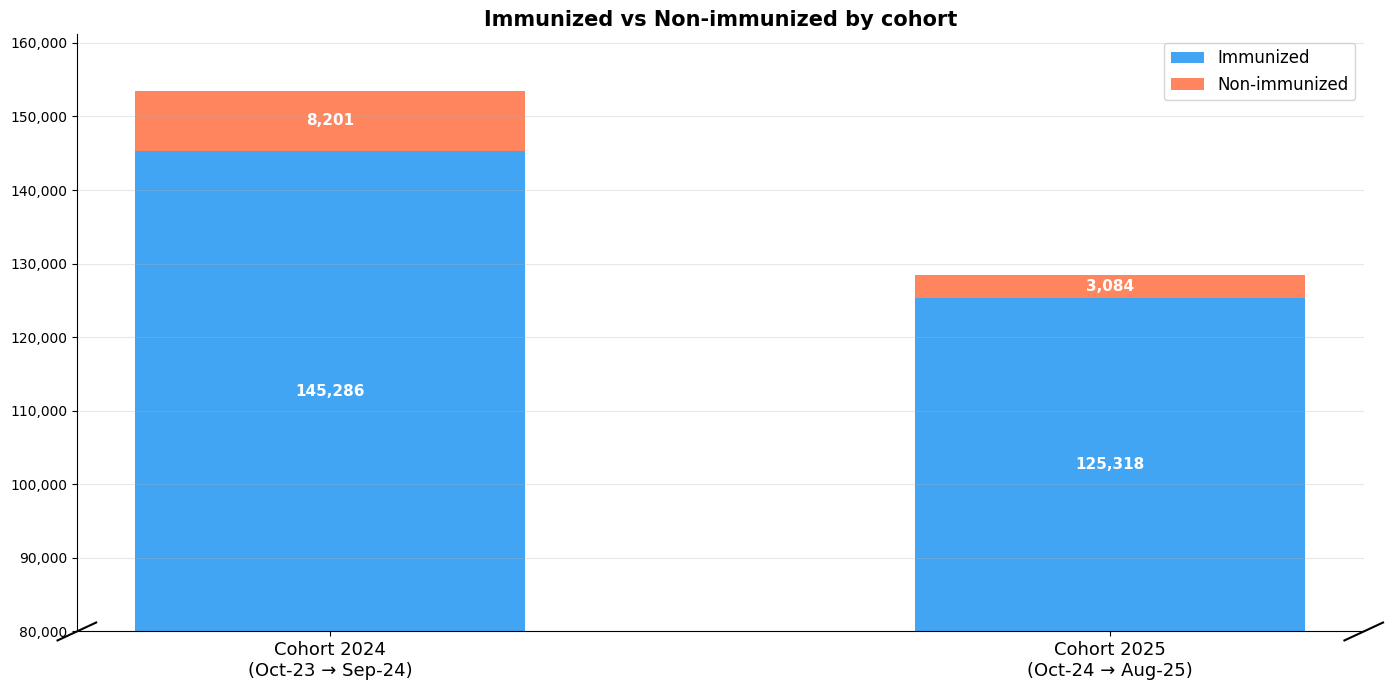

In [164]:
import matplotlib.ticker as mticker

cohort_2024 = {
    'October': 'Oct-23', 'November': 'Nov-23', 'December': 'Dec-23',
    'January': 'Jan-24', 'February': 'Feb-24', 'March': 'Mar-24',
    'April': 'Apr-24', 'May': 'May-24', 'June': 'Jun-24',
    'July': 'Jul-24', 'August': 'Aug-24', 'September': 'Sep-24'
}

cohort_2025 = {
    'October': 'Oct-24', 'November': 'Nov-24', 'December': 'Dec-24',
    'January': 'Jan-25', 'February': 'Feb-25', 'March': 'Mar-25',
    'April': 'Apr-25', 'May': 'May-25', 'June': 'Jun-25',
    'July': 'Jul-25', 'August': 'Aug-25'  # sin Sep-25
}

# Datos base numéricos
df_plot = (df_cox_vrs_tramos_2year_mod_2
           .groupby('RUN', as_index=False)
           .agg({'inmunizado':'max','mes_nac_name':'first','year_nac':'first'})           
           .groupby(['inmunizado','mes_nac_name','year_nac'])
           .RUN.nunique()
           .unstack(['year_nac','inmunizado'])
           .fillna(0)
           .reindex(orden_meses)
)

# Armar datos por cohorte
def get_cohort_data(year_no_imm, year_imm, meses_dict):
    meses = list(meses_dict.keys())
    labels = list(meses_dict.values())
    imm    = df_plot.loc[meses, (year_imm, 1.0)].values
    no_imm = df_plot.loc[meses, (year_no_imm, 0.0)].values
    return labels, imm, no_imm

# Cohort 2024: oct-nov-dic vienen de year_nac=2023, resto de 2024
# Necesitamos combinar filas de distintos years
def get_cohort(cohort_def, year_map):
    """
    cohort_def: dict {mes: label}
    year_map: dict {mes: (year_no_imm, year_imm)}
    """
    labels, imm_vals, no_imm_vals = [], [], []
    for mes, label in cohort_def.items():
        y_no_imm, y_imm = year_map[mes]
        imm_vals.append(df_plot.loc[mes, (y_imm, 1.0)] if (y_imm, 1.0) in df_plot.columns else 0)
        no_imm_vals.append(df_plot.loc[mes, (y_no_imm, 0.0)] if (y_no_imm, 0.0) in df_plot.columns else 0)
        labels.append(label)
    return labels, np.array(imm_vals), np.array(no_imm_vals)

# Oct/Nov/Dec = year 2023, resto = year 2024
year_map_2024 = {m: (2023, 2023) if m in ['October','November','December'] else (2024, 2024) 
                 for m in cohort_2024}

# Oct/Nov/Dec = year 2024, resto = year 2025
year_map_2025 = {m: (2024, 2024) if m in ['October','November','December'] else (2025, 2025) 
                 for m in cohort_2025}

labels_2024, imm_2024, no_imm_2024 = get_cohort(cohort_2024, year_map_2024)
labels_2025, imm_2025, no_imm_2025 = get_cohort(cohort_2025, year_map_2025)

# Totales por cohorte
total_imm_2024    = imm_2024.sum()
total_no_imm_2024 = no_imm_2024.sum()
total_imm_2025    = imm_2025.sum()
total_no_imm_2025 = no_imm_2025.sum()

fig, ax = plt.subplots(figsize=(14, 7))

bars_imm    = [total_imm_2024, total_imm_2025]
bars_no_imm = [total_no_imm_2024, total_no_imm_2025]

x = np.arange(2)
labels_cohort = ['Cohort 2024\n(Oct-23 → Sep-24)', 'Cohort 2025\n(Oct-24 → Aug-25)']

b1 = ax.bar(x, bars_imm,    width=0.5, label='Immunized',    color='#2196F3', alpha=0.85)
b2 = ax.bar(x, bars_no_imm, width=0.5, label='Non-immunized', color='#FF7043', alpha=0.85,
            bottom=bars_imm)

# Etiquetas dentro de ambos segmentos
for i, (imm, no_imm) in enumerate(zip(bars_imm, bars_no_imm)):
    ax.text(i, imm/2 + 40000,          f'{int(imm):,}',    ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(i, imm + no_imm/2, f'{int(no_imm):,}', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Partir eje desde 80000
y_min = 80000
y_max = max([i + n for i, n in zip(bars_imm, bars_no_imm)]) * 1.05
ax.set_ylim(y_min, y_max)

# Símbolo de quiebre en el eje y (líneas diagonales)
d = 0.015
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False, lw=1.5)
ax.plot((-d, +d), (-d, +d), **kwargs)        # línea inferior izquierda
ax.plot((1-d, 1+d), (-d, +d), **kwargs)      # línea inferior derecha

# Triángulo / doble línea para indicar corte
ax.annotate('', xy=(-0.07, 0.02), xycoords='axes fraction',
            xytext=(-0.07, -0.02), textcoords='axes fraction',
            annotation_clip=False)

ax.set_xticks(x)
ax.set_xticklabels(labels_cohort, fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=12)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Immunized vs Non-immunized by cohort', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [211]:
df_imm.query('eleg_group_fix=="seasonal_2024"')[['fecha_nac','fechaInm']]

,fecha_nac,fechaInm
323,2024-04-04,2024-04-05
328,2024-04-06,2024-04-07
329,2024-04-06,2024-04-07
334,2024-04-08,2024-04-10
337,2024-04-10,2024-04-12
...,...,...
115720,2024-05-21,2024-05-22
108731,2024-05-06,2024-05-10
176511,2024-09-28,2024-09-30
135262,2024-06-30,2024-07-01


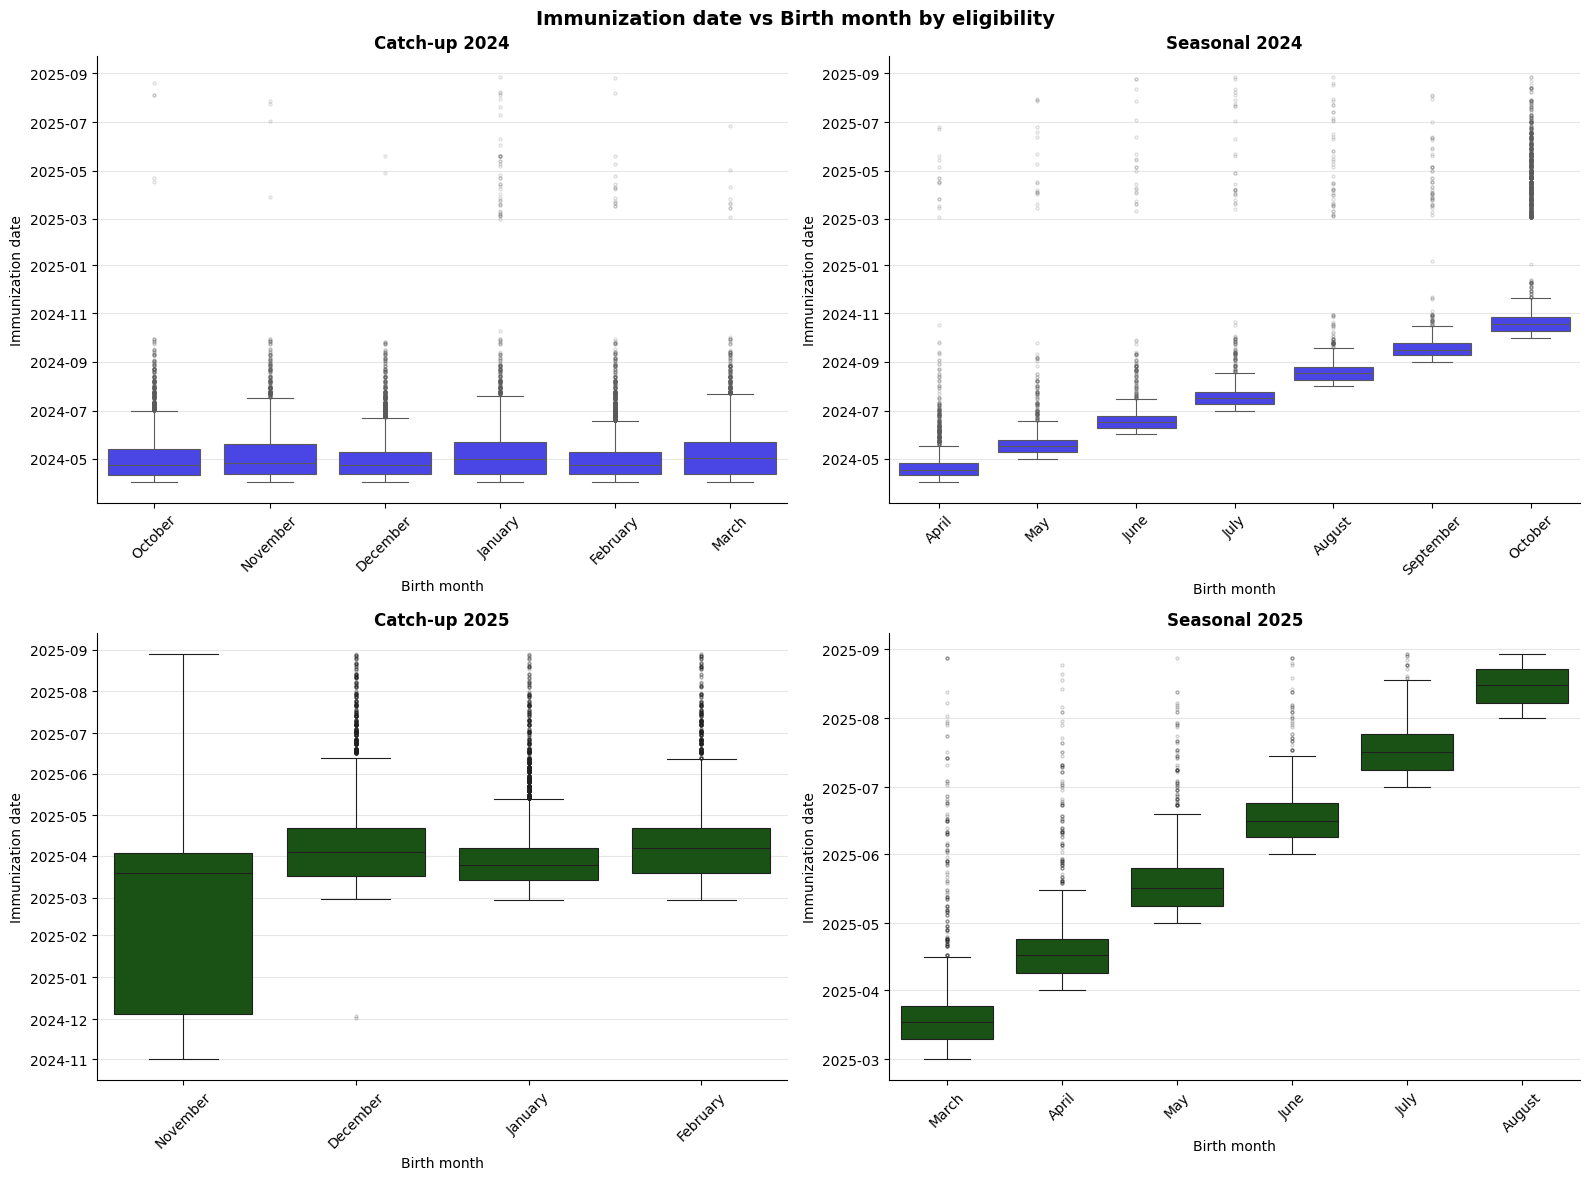

In [ ]:
df_f_vrs_tramos_final_plot = df_f_vrs_tramos_final.copy()
df_f_vrs_tramos_final_plot['edad_inmunizacion'] = (
    df_f_vrs_tramos_final_plot['fechaInm'] - df_f_vrs_tramos_final_plot['fecha_nac']
).dt.days

# Solo inmunizados
df_imm = (df_f_vrs_tramos_final_plot
          .assign(eleg_group_fix = lambda x: np.where((x.eleg_group=='exceso_seasonal_2024_and_catchup_2025') & (x.fecha_nac < '2024-11-01'),
                                                      'seasonal_2024',
                                                      np.where(x.eleg_group=='exceso_seasonal_2024_and_catchup_2025',
                                                               'catchup_2025',
                                                               x.eleg_group)
                                                      )
                  )
          .query('inmunizado == 1')
          .copy()
)

df_plot_corr = df_imm[df_imm['eleg_group_fix'].isin(['catchup_2024', 'seasonal_2024','catchup_2025','seasonal_2025'])].copy()
df_plot_corr['fechaInm'] = pd.to_datetime(df_plot_corr['fechaInm'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

title_dic = {'catchup_2024': 'Catch-up 2024',
             'seasonal_2024': 'Seasonal 2024',
             'catchup_2025': 'Catch-up 2025',
             'seasonal_2025': 'Seasonal 2025'}

colores = {'catchup_2024': "#2F2CFF9E",'seasonal_2024': "#2F2CFF9E",'catchup_2025': "#125C0BFF",'seasonal_2025': "#125C0BFF"}

for ax, cat in zip(axes, ['catchup_2024', 'seasonal_2024', 'catchup_2025', 'seasonal_2025']):
    df_sub = df_plot_corr[df_plot_corr['eleg_group_fix'] == cat].copy()
    
    # Solo meses presentes en este grupo
    order = [m for m in orden_meses if m in df_sub['mes_nac_name'].unique()]
    if cat=='seasonal_2024':
        order=['April','May','June','July','August','September','October']
    sns.boxplot(
        data=df_sub,
        x='mes_nac_name',
        y='fechaInm',
        order=order,
        ax=ax,
        color=colores[cat],
        flierprops=dict(marker='o', markersize=2, alpha=0.2),
        linewidth=0.8
    )
    
    ax.set_title(title_dic[cat], fontsize=12, fontweight='bold')
    ax.set_xlabel('Birth month')
    ax.set_ylabel('Immunization date')
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Immunization date vs Birth month by eligibility',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

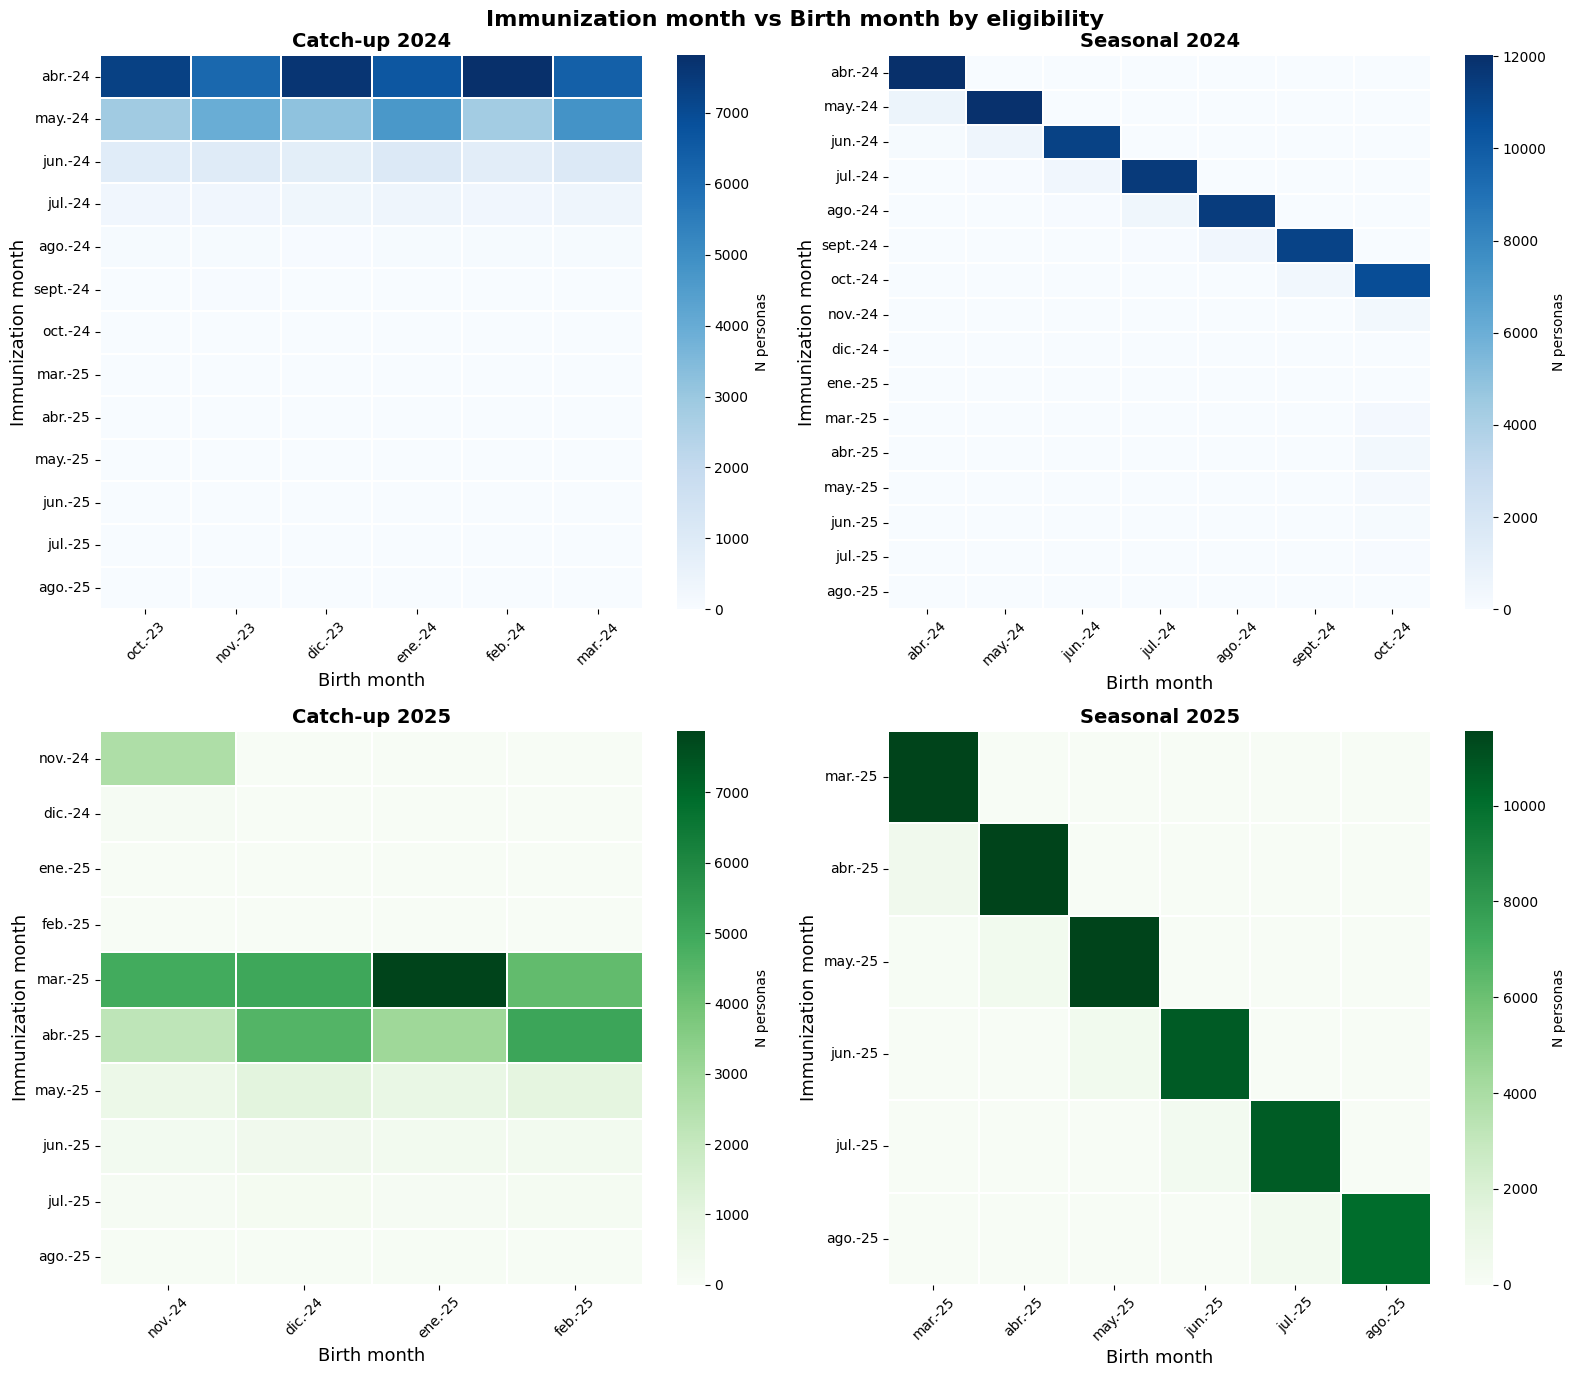

In [225]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

order_dic = {
    'catchup_2024':  ['October','November','December','January','February','March'],
    'seasonal_2024': ['April','May','June','July','August','September','October'],
    'catchup_2025':  ['November','December','January','February'],
    'seasonal_2025': ['March','April','May','June','July','August'],
}

for ax, cat in zip(axes, ['catchup_2024', 'seasonal_2024', 'catchup_2025', 'seasonal_2025']):
    df_sub = df_plot_corr[df_plot_corr['eleg_group_fix'] == cat].copy()
    df_sub['imm_month'] = df_sub['fechaInm'].dt.strftime('%b-%y')
    df_sub['birth_month_label'] = df_sub['fecha_nac'].dt.strftime('%b-%y')
    
    # Orden cronológico eje x (nacimiento)
    birth_order = [m for m in order_dic[cat] 
                   if any(df_sub['mes_nac_name'] == m)]
    birth_label_order = (df_sub[df_sub['mes_nac_name'].isin(birth_order)]
                         .assign(fecha_nac=lambda x: pd.to_datetime(x['fecha_nac']))
                         .groupby('mes_nac_name')['fecha_nac'].min()
                         .reindex(birth_order)
                         .reset_index()
                         .assign(label=lambda x: x['fecha_nac'].dt.strftime('%b-%y'))
                         ['label'].tolist())
    
    # Orden cronológico eje y (inmunización)
    imm_label_order = sorted(df_sub['imm_month'].unique(),
                             key=lambda x: pd.to_datetime(x, format='%b-%y'))
    
    # Pivot para heatmap
    pivot = (df_sub.groupby(['birth_month_label','imm_month'])
             .size()
             .unstack(fill_value=0)
             .reindex(index=birth_label_order, columns=imm_label_order, fill_value=0))
    
    cmap = 'Blues' if '2024' in cat else 'Greens'
    sns.heatmap(pivot.T, ax=ax, cmap=cmap, linewidths=0.3,
                cbar_kws={'label': 'N personas'}, fmt='d', annot= False) #len(pivot.columns) <= 8
    
    ax.set_title(title_dic[cat], fontsize=14, fontweight='bold')
    ax.set_xlabel('Birth month',fontsize=13)
    ax.set_ylabel('Immunization month',fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Immunization month vs Birth month by eligibility',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

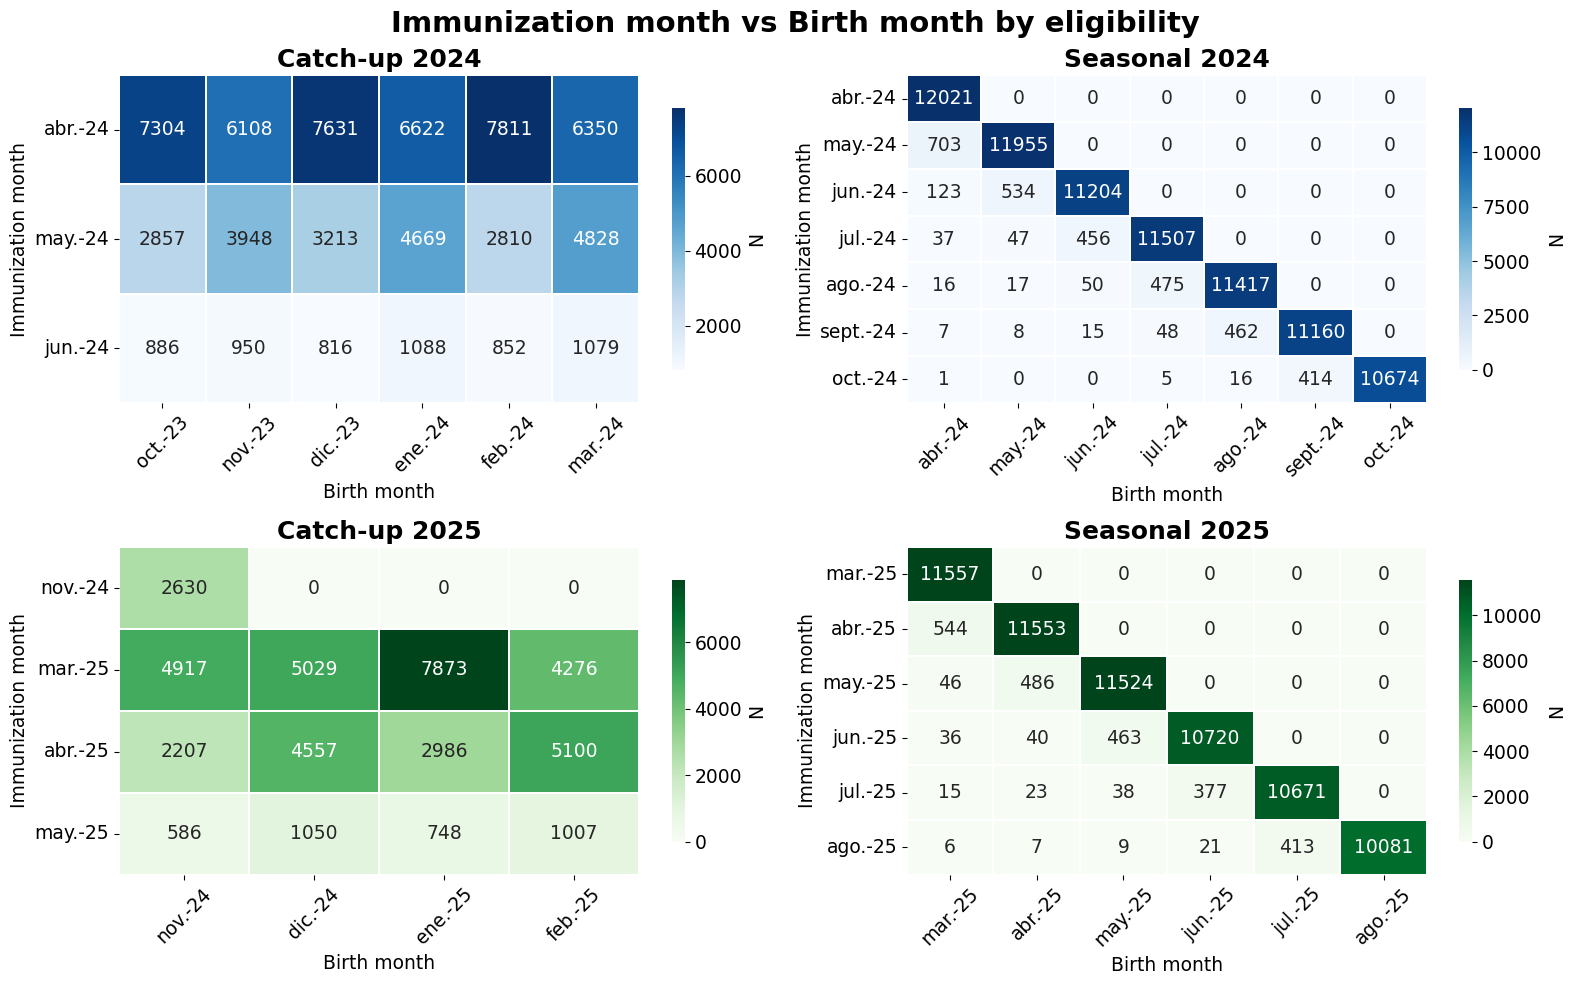

In [230]:
import calendar
import locale

# Parámetro global de escala de fuente
FONT_SCALE = 1.5  # aumenta o disminuye todas las fuentes proporcionalmente
BASE = 9  # tamaño base

def to_eng_month_label(series):
    return series.dt.strftime('%m-%y').map(
        lambda x: f"{calendar.month_abbr[int(x.split('-')[0])]}-{x.split('-')[1]}"
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

order_dic = {
    'catchup_2024':  ['October','November','December','January','February','March'],
    'seasonal_2024': ['April','May','June','July','August','September','October'],
    'catchup_2025':  ['November','December','January','February'],
    'seasonal_2025': ['March','April','May','June','July','August'],
}

THRESHOLD = 0.05

for ax, cat in zip(axes, ['catchup_2024', 'seasonal_2024', 'catchup_2025', 'seasonal_2025']):
    df_sub = df_plot_corr[df_plot_corr['eleg_group_fix'] == cat].copy()
    df_sub['imm_month']         = to_eng_month_label(df_sub['fechaInm'])
    df_sub['birth_month_label'] = to_eng_month_label(df_sub['fecha_nac'])
    
    birth_order = [m for m in order_dic[cat] if m in df_sub['mes_nac_name'].unique()]
    birth_label_order = (df_sub[df_sub['mes_nac_name'].isin(birth_order)]
                         .groupby('mes_nac_name')['fecha_nac'].min()
                         .reindex(birth_order)
                         .reset_index()
                         .assign(label=lambda x: to_eng_month_label(x['fecha_nac']))
                         ['label'].tolist())
    
    imm_label_order = sorted(df_sub['imm_month'].unique(),
                             key=lambda x: pd.to_datetime(x, format='%b-%y'))
    
    pivot = (df_sub.groupby(['birth_month_label','imm_month'])
             .size()
             .unstack(fill_value=0)
             .reindex(index=birth_label_order, columns=imm_label_order, fill_value=0))
    
    row_max = pivot.T.max(axis=1)
    pivot = pivot.T.loc[row_max >= row_max.max() * THRESHOLD].T
    col_max = pivot.max(axis=0)
    pivot = pivot.loc[:, col_max >= col_max.max() * THRESHOLD]

    cmap = 'Blues' if '2024' in cat else 'Greens'
    sns.heatmap(pivot.T, ax=ax, cmap=cmap, linewidths=0.3,
                cbar_kws={'label': 'N', 'shrink': 0.8},
                annot=len(pivot.columns) <= 8, fmt='d',
                annot_kws={'size': BASE * FONT_SCALE})
    # Override forzado por si seaborn regenera las etiquetas
    new_ylabels = [to_eng_month_label(pd.Series([pd.to_datetime(t.get_text(), format='%b-%y')])).iloc[0] 
                if t.get_text() else '' for t in ax.get_yticklabels()]
    ax.set_yticklabels(new_ylabels, fontsize=BASE * FONT_SCALE)
    
    ax.set_title(title_dic[cat], fontsize=12 * FONT_SCALE, fontweight='bold')
    ax.set_xlabel('Birth month',      fontsize=BASE * FONT_SCALE)
    ax.set_ylabel('Immunization month', fontsize=BASE * FONT_SCALE)
    ax.tick_params(axis='x', rotation=45, labelsize=BASE * FONT_SCALE)
    ax.tick_params(axis='y', rotation=0,  labelsize=BASE * FONT_SCALE)
    
    # Forzar labels en inglés manualmente sobre los ticks existentes
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=BASE * FONT_SCALE)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=BASE * FONT_SCALE)

    # Colorbar fontsize
    ax.collections[0].colorbar.ax.tick_params(labelsize=BASE * FONT_SCALE)
    ax.collections[0].colorbar.ax.set_ylabel('N', fontsize=BASE * FONT_SCALE)

fig.suptitle('Immunization month vs Birth month by eligibility',
             fontsize=14 * FONT_SCALE, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac']  # 

df_tv = df_cox_vrs_tramos_2year_mod_2.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

1:1 ['1', '1']
here aaa
Total cases = 11285, Total controls = 270604
Total cases matched is : 11285, Total control matched is : 11285
ratio: 1:1
No matched : 0


In [ ]:
df_tv_matched_2 = (df_tv_matched
                   [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_2['inm_mayor_meses_agg_0_2'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses','inm_mayor_2_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_3_5'] = df_tv_matched_2[["inm_mayor_3_meses" ,'inm_mayor_4_meses','inm_mayor_5_meses']].sum(axis=1)
# df_tv_matched_2['inm_mayor_meses_agg_6'] = df_tv_matched_2[["inm_mayor_6_meses"]].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_mas_de_6'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(6,17)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_2','inm_mayor_meses_agg_3_5','inm_mayor_meses_agg_mas_de_6'] #inm_mayor_meses_agg_6

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 7.61e-01, step_size = 0.9500, log_lik = -126.15279, newton_decrement = 3.06e+01, seconds_since_start = 10.9
Iteration 2: norm_delta = 1.98e-01, step_size = 0.9500, log_lik = -93.72414, newton_decrement = 1.45e+00, seconds_since_start = 21.1
Iteration 3: norm_delta = 4.32e-02, step_size = 0.9500, log_lik = -92.17494, newton_decrement = 5.28e-02, seconds_since_start = 31.7
Iteration 4: norm_delta = 4.07e-03, step_size = 1.0000, log_lik = -92.12112, newton_decrement = 3.94e-04, seconds_since_start = 42.2
Iteration 5: norm_delta = 1.44e-05, step_size = 1.0000, log_lik = -92.12072, newton_decrement = 4.90e-09, seconds_since_start = 52.4
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_meses_agg_0_2,0.861111,0.730895,0.928318,0.000000,-1.974081,0.337470,-2.635510,-1.312652
inm_mayor_meses_agg_3_5,0.718750,0.410807,0.865746,0.000774,-1.268511,0.377308,-2.008021,-0.529002
inm_mayor_meses_agg_mas_de_6,-0.666667,-2.808438,0.270625,0.225693,0.510826,0.421637,-0.315568,1.337219


In [18]:
df_tv_matched_2 = (df_tv_matched
                   [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_2['inm_mayor_meses_agg_0_1'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_2_3'] = df_tv_matched_2[["inm_mayor_2_meses" ,'inm_mayor_3_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_4_5'] = df_tv_matched_2[["inm_mayor_4_meses" ,'inm_mayor_5_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_mas_de_6'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(6,13)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_1','inm_mayor_meses_agg_2_3','inm_mayor_meses_agg_4_5','inm_mayor_meses_agg_mas_de_6'] #inm_mayor_meses_agg_6

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 8.14e-01, step_size = 0.9500, log_lik = -126.15279, newton_decrement = 3.09e+01, seconds_since_start = 11.0
Iteration 2: norm_delta = 2.40e-01, step_size = 0.9500, log_lik = -93.39778, newton_decrement = 1.63e+00, seconds_since_start = 21.3
Iteration 3: norm_delta = 7.35e-02, step_size = 0.9500, log_lik = -91.62529, newton_decrement = 9.55e-02, seconds_since_start = 31.5
Iteration 4: norm_delta = 1.07e-02, step_size = 1.0000, log_lik = -91.52599, newton_decrement = 1.53e-03, seconds_since_start = 41.7
Iteration 5: norm_delta = 1.28e-04, step_size = 1.0000, log_lik = -91.52445, newton_decrement = 2.11e-07, seconds_since_start = 52.1
Iteration 6: norm_delta = 1.80e-08, step_size = 1.0000, log_lik = -91.52444, newton_decrement = 4.20e-15, seconds_since_start = 62.4
Convergence completed after 6 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_meses_agg_0_1,0.906977,0.740852,0.966608,0.000005,-2.374906,0.522739,-3.399455,-1.350357
inm_mayor_meses_agg_2_3,0.765957,0.548771,0.878607,0.000015,-1.452252,0.334941,-2.108725,-0.795779
inm_mayor_meses_agg_4_5,0.714286,0.132004,0.905953,0.027128,-1.252763,0.566947,-2.363958,-0.141568
inm_mayor_meses_agg_mas_de_6,-0.666667,-2.808438,0.270625,0.225693,0.510826,0.421637,-0.315568,1.337219


In [19]:
df_tv_matched_2 = (df_tv_matched
                   [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_2['inm_mayor_meses_agg_0_1'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_2_3'] = df_tv_matched_2[["inm_mayor_2_meses" ,'inm_mayor_3_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_4_5'] = df_tv_matched_2[["inm_mayor_4_meses" ,'inm_mayor_5_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_6_8'] = df_tv_matched_2[["inm_mayor_6_meses" ,'inm_mayor_7_meses','inm_mayor_8_meses']].sum(axis=1)

df_tv_matched_2['inm_mayor_meses_agg_mas_de_8'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(9,13)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_1','inm_mayor_meses_agg_2_3','inm_mayor_meses_agg_4_5','inm_mayor_meses_agg_6_8','inm_mayor_meses_agg_mas_de_8'] #inm_mayor_meses_agg_6

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 8.40e-01, step_size = 0.9500, log_lik = -126.15279, newton_decrement = 3.10e+01, seconds_since_start = 10.3
Iteration 2: norm_delta = 2.42e-01, step_size = 0.9500, log_lik = -93.23626, newton_decrement = 1.63e+00, seconds_since_start = 20.3
Iteration 3: norm_delta = 7.36e-02, step_size = 0.9500, log_lik = -91.45740, newton_decrement = 9.55e-02, seconds_since_start = 30.3
Iteration 4: norm_delta = 1.07e-02, step_size = 1.0000, log_lik = -91.35805, newton_decrement = 1.53e-03, seconds_since_start = 40.3
Iteration 5: norm_delta = 1.28e-04, step_size = 1.0000, log_lik = -91.35650, newton_decrement = 2.11e-07, seconds_since_start = 50.4
Iteration 6: norm_delta = 1.80e-08, step_size = 1.0000, log_lik = -91.35650, newton_decrement = 4.20e-15, seconds_since_start = 60.5
Convergence completed after 6 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_meses_agg_0_1,0.906977,0.740852,0.966608,0.000005,-2.374906,0.522739,-3.399455,-1.350357
inm_mayor_meses_agg_2_3,0.765957,0.548771,0.878607,0.000015,-1.452252,0.334941,-2.108725,-0.795779
inm_mayor_meses_agg_4_5,0.714286,0.132004,0.905953,0.027128,-1.252763,0.566947,-2.363958,-0.141568
inm_mayor_meses_agg_6_8,-2.000000,-27.840590,0.687940,0.341388,1.098612,1.154700,-1.164559,3.361784
inm_mayor_meses_agg_mas_de_8,-0.500000,-2.669525,0.386842,0.374364,0.405465,0.456435,-0.489132,1.300062


In [20]:
df_tv_matched_2 = (df_tv_matched
                   [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

columns_inm = [f"inm_mayor_{k}_meses" for k in range(13) if not ((k>=6) & (k<=7))] #) 
# columns_inm = [f"inm_mayor_{k}_meses" for k in range(12)]
ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 8.87e-01, step_size = 0.9500, log_lik = -126.15279, newton_decrement = 3.56e+01, seconds_since_start = 10.2
Iteration 2: norm_delta = 2.85e-01, step_size = 0.9500, log_lik = -88.19689, newton_decrement = 2.18e+00, seconds_since_start = 20.4
Iteration 3: norm_delta = 1.26e-01, step_size = 0.9500, log_lik = -85.77668, newton_decrement = 2.29e-01, seconds_since_start = 30.4
Iteration 4: norm_delta = 1.00e-01, step_size = 1.0000, log_lik = -85.51552, newton_decrement = 4.79e-02, seconds_since_start = 40.4
Iteration 5: norm_delta = 9.83e-02, step_size = 1.0000, log_lik = -85.45548, newton_decrement = 1.67e-02, seconds_since_start = 50.5
Iteration 6: norm_delta = 9.79e-02, step_size = 1.0000, log_lik = -85.43437, newton_decrement = 6.10e-03, seconds_since_start = 60.3
Iteration 7: norm_delta = 9.78e-02, step_size = 1.0000, log_lik = -85.42665, newton_decrement = 2.24e-03, seconds_since_start = 70.7
Iteration 8: norm_delta = 9.77e-02, step_size = 1.0000, log_lik = -8

,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_0_meses,9.130435e-01,0.631178,0.979498,0.000923,-2.442347,0.737210,-3.887252,-0.997442
inm_mayor_1_meses,9.000000e-01,0.572173,0.976626,0.001904,-2.302585,0.741620,-3.756133,-0.849037
inm_mayor_2_meses,7.931034e-01,0.501673,0.914100,0.000443,-1.575536,0.448497,-2.454574,-0.696499
inm_mayor_3_meses,7.222222e-01,0.251829,0.896868,0.011281,-1.280934,0.505525,-2.271745,-0.290123
inm_mayor_4_meses,8.461538e-01,0.318257,0.965282,0.013727,-1.871802,0.759555,-3.360502,-0.383103
inm_mayor_5_meses,-1.000000e+00,-21.056405,0.818647,0.571426,0.693147,1.224745,-1.707309,3.093603
inm_mayor_8_meses,-2.000000e+00,-27.840590,0.687940,0.341388,1.098612,1.154700,-1.164559,3.361784
inm_mayor_9_meses,-0.000000e+00,-14.987508,0.937451,1.000000,0.000000,1.414214,-2.771808,2.771808
inm_mayor_10_meses,5.000000e-01,-0.999219,0.874951,0.326959,-0.693147,0.707107,-2.079051,0.692757


In [ ]:
df_f_vrs_tramos_2year, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2024',
                                                        T_inicial = pd.to_datetime('2025-03-01'),
                                                        fecha_dt = pd.to_datetime('2025-08-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=True)

In [ ]:

meses = list(range(0, 17))  # 0..16
EVENT_COL = "event_vrs"
EV_DATE   = "fechaIng_vrs"
INM_DATE  = "fechaInm"

df = (df_f_vrs_tramos_final
      .assign(year_nac = lambda x: x.fecha_nac.dt.year,
              edad_relative = lambda x: x.fecha_nac -pd.to_datetime('2023-01-10'))
      [['RUN','fecha_nac','mes_nac_name','semana_nac',P
        'SEMANAS','PESO','prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
        'sexo','region','year_nac','eleg_group','eleg_2025','eleg_2024', 'MARCA', 'edad_relative',
        'event_vrs','fechaIng_vrs','fechaInm','inmunizado'] +
       [col for col in df_f_vrs_tramos_final.columns if col.startswith('inm_')]]
      .copy())

# Asegurar datetime
df[EV_DATE]  = pd.to_datetime(df[EV_DATE], errors="coerce")
df[INM_DATE] = pd.to_datetime(df[INM_DATE], errors="coerce")

# Eventos válidos
mask_event = df[EVENT_COL].eq(1) & df[EV_DATE].notna()

# Inicializa columna
df["evento_when_inmu"] = pd.NA

# Casos con evento pero sin fechaInm -> "never_inm"
mask_event_never = mask_event & df[INM_DATE].isna()
df.loc[mask_event_never, "evento_when_inmu"] = "never_inm"

# Casos con evento y con fechaInm
mask_event_has_inm = mask_event & df[INM_DATE].notna()

# Umbrales: fechaInm + m meses (m=0..16)  => matriz n x 17
thr = np.column_stack([
    (df.loc[mask_event_has_inm, INM_DATE] + pd.DateOffset(months=m)).to_numpy(dtype="datetime64[ns]")
    for m in meses
])

ev = df.loc[mask_event_has_inm, EV_DATE].to_numpy(dtype="datetime64[ns]")

# months_idx = #umbrales cumplidos - 1
# -1 => evento antes de inmunizarse
ge = ev[:, None] >= thr
m_idx = ge.sum(axis=1) - 1

# Etiquetas
labels = np.array([f"inm_{m}_meses" for m in meses], dtype=object)

evento_labels = np.where(
    m_idx < 0,
    "pre_inm",                       # evento ocurrió antes de fechaInm
    labels[np.clip(m_idx, 0, len(meses)-1)]  # si pasa de 16, lo dejamos como inm_16_meses
)

df.loc[mask_event_has_inm, "evento_when_inmu"] = evento_labels

# (opcional) ordenar categoría para tablas bonitas
ordered = ["never_inm", "pre_inm"] + [f"inm_{m}_meses" for m in meses]
df["evento_when_inmu"] = pd.Categorical(df["evento_when_inmu"], categories=ordered, ordered=True)

In [ ]:
df_cases   = df.query("inmunizado == 0").copy()  
df_control = df.query("inm_mayor_0_meses == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_matched = df.merge(match_map, on="RUN", how="inner").copy()

1:2 ['1', '2']
here aaa
Total cases = 12280, Total controls = 282831
Total cases matched is : 7702, Total control matched is : 15404
ratio: 1:2
No matched : 4578


In [29]:
 ############################################################### CREACION DF COMPLETO ################################################################
meses = list(range(0, 17))  # 0..16
EVENT_COL = "event_vrs"
EV_DATE   = "fechaIng_vrs"
INM_DATE  = "fechaInm"

df = (df_f_vrs_tramos_final
      .assign(year_nac = lambda x: x.fecha_nac.dt.year,
              edad_relative = lambda x: x.fecha_nac -pd.to_datetime('2023-01-10'))
      [['RUN','fecha_nac','mes_nac_name','semana_nac',
        'SEMANAS','PESO','prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
        'sexo','region','year_nac','eleg_group','eleg_2025','eleg_2024', 'MARCA', 'edad_relative',
        'event_vrs','fechaIng_vrs','fechaInm','inmunizado'] +
       [col for col in df_f_vrs_tramos_final.columns if col.startswith('inm_')]]
      .copy())

# Asegurar datetime
df[EV_DATE]  = pd.to_datetime(df[EV_DATE], errors="coerce")
df[INM_DATE] = pd.to_datetime(df[INM_DATE], errors="coerce")

# Eventos válidos
mask_event = df[EVENT_COL].eq(1) & df[EV_DATE].notna()

# Inicializa columna
df["evento_when_inmu"] = pd.NA

# Casos con evento pero sin fechaInm -> "never_inm"
mask_event_never = mask_event & df[INM_DATE].isna()
df.loc[mask_event_never, "evento_when_inmu"] = "never_inm"

# Casos con evento y con fechaInm
mask_event_has_inm = mask_event & df[INM_DATE].notna()

# Umbrales: fechaInm + m meses (m=0..16)  => matriz n x 17
thr = np.column_stack([
    (df.loc[mask_event_has_inm, INM_DATE] + pd.DateOffset(months=m)).to_numpy(dtype="datetime64[ns]")
    for m in meses
])

ev = df.loc[mask_event_has_inm, EV_DATE].to_numpy(dtype="datetime64[ns]")

# months_idx = #umbrales cumplidos - 1
# -1 => evento antes de inmunizarse
ge = ev[:, None] >= thr
m_idx = ge.sum(axis=1) - 1

# Etiquetas
labels = np.array([f"inm_{m}_meses" for m in meses], dtype=object)

evento_labels = np.where(
    m_idx < 0,
    "pre_inm",                       # evento ocurrió antes de fechaInm
    labels[np.clip(m_idx, 0, len(meses)-1)]  # si pasa de 16, lo dejamos como inm_16_meses
)

df.loc[mask_event_has_inm, "evento_when_inmu"] = evento_labels

# (opcional) ordenar categoría para tablas bonitas
ordered = ["never_inm", "pre_inm"] + [f"inm_{m}_meses" for m in meses]
df["evento_when_inmu"] = pd.Categorical(df["evento_when_inmu"], categories=ordered, ordered=True)

mask = df["inmunizado"].eq(1) & df["event_vrs"].eq(1) & df["fechaIng_vrs"].notna()

# create output column
df["k_window_event"] = np.nan

# assign k where fechaIng_vrs in [inm_k, inm_{k+1})
for k in range(16):
    s, e = f"inm_{k}_meses", f"inm_{k+1}_meses"
    if s not in df.columns or e not in df.columns:
        if k==16:
            cond_k = (
                mask
                & df[s].notna()
                & df["fechaIng_vrs"].ge(df[s])
            )
            df.loc[cond_k, "k_window_event"] = k
            continue
        else:
            continue

    cond_k = (
        mask
        & df[s].notna() & df[e].notna()
        & df["fechaIng_vrs"].ge(df[s])
        & df["fechaIng_vrs"].lt(df[e])   # [start, end)
    )
    df.loc[cond_k, "k_window_event"] = k

# (optional) if you want an integer dtype with missing values
df["k_window_event"] = df["k_window_event"].astype("Int64")

for k in range(1,17):
    df.loc[(df[f'inm_{k}_meses']>=df.fechaIng_vrs), f'inm_mayor_{k}_meses'] = -1


In [30]:
runs_no_inm_vrs = df.query('inmunizado==0').query('fechaIng_vrs.notna()').groupby(['year_nac','mes_nac_name']).agg({'RUN':'nunique'}).rename(columns={'RUN':'RUN_vrs'})
(df
 .query('inmunizado==0')
 .query('fechaIng_vrs.isna()')
 .groupby(['year_nac','mes_nac_name'])
 .agg({'RUN':'nunique'})
 .rename(columns={'RUN':'RUN_no_vrs'})
 .merge(runs_no_inm_vrs,how='left',on=['year_nac','mes_nac_name'])
 .assign(all_run = lambda x: x.RUN_vrs + x.RUN_no_vrs,
         prop_porcentaje = lambda x: round(x.RUN_vrs*100/x.all_run,2))
 )

RUN_no_vrs  RUN_vrs  all_run  prop_porcentaje
year_nac mes_nac_name                                               
2023     December             981      9.0    990.0             0.91
         November            1330     12.0   1342.0             0.89
         October             1870     18.0   1888.0             0.95
2024     April                257      1.0    258.0             0.39
         August               287      2.0    289.0             0.69
         December             532     39.0    571.0             6.83
         February             774      4.0    778.0             0.51
         January              943      7.0    950.0             0.74
         July                 240      3.0    243.0             1.23
         June                 219      4.0    223.0             1.79
         March                699      5.0    704.0             0.71
         May                  212      2.0    214.0             0.93
         November             470     19.0    489.0             3.89
         October              127      1.0    128.0             0.78
         September            316      6.0    322.0             1.86
2025     April                186      6.0    192.0             3.12
         August               223      3.0    226.0             1.33
         February             329     32.0    361.0             8.86
         January              453     36.0    489.0             7.36
         July                 157      3.0    160.0             1.88
         June                 162     10.0    172.0             5.81
         March                134      1.0    135.0             0.74
         May                  164      8.0    172.0             4.65
         September            392      NaN      NaN              NaN

In [31]:
runs_no_inm_vrs = df.query('inmunizado==1').query('fechaIng_vrs.notna()').groupby(['year_nac','mes_nac_name']).agg({'RUN':'nunique'}).rename(columns={'RUN':'RUN_vrs'})
(df
 .query('inmunizado==1')
 .query('fechaIng_vrs.isna()')
 .groupby(['year_nac','mes_nac_name'])
 .agg({'RUN':'nunique'})
 .rename(columns={'RUN':'RUN_no_vrs'})
 .merge(runs_no_inm_vrs,how='left',on=['year_nac','mes_nac_name'])
 .assign(all_run = lambda x: x.RUN_vrs + x.RUN_no_vrs,
         prop_porcentaje = lambda x: round(x.RUN_vrs*100/x.all_run,2))
 )

RUN_no_vrs  RUN_vrs  all_run  prop_porcentaje
year_nac mes_nac_name                                               
2023     December           11914      146    12060             1.21
         November           11282      124    11406             1.09
         October            11338      117    11455             1.02
2024     April              12747      176    12923             1.36
         August             11727      213    11940             1.78
         December           11239      100    11339             0.88
         February           11712      167    11879             1.41
         January            12720      163    12883             1.27
         July               11858      204    12062             1.69
         June               11576      170    11746             1.45
         March              12564      171    12735             1.34
         May                12381      197    12578             1.57
         November           10818       97    10915             0.89
         October            11845       95    11940             0.80
         September          11423      201    11624             1.73
2025     April              11892      219    12111             1.81
         August             10696       38    10734             0.35
         February           10770      138    10908             1.27
         January            11967      126    12093             1.04
         July               11003      105    11108             0.95
         June               10957      169    11126             1.52
         March              12009      200    12209             1.64
         May                11833      203    12036             1.69
         September          10279        4    10283             0.04

Método 4: Denis ratio

In [204]:

 ############################################################### CREACION DF COMPLETO ################################################################
meses = list(range(0, 17))  # 0..16
EVENT_COL = "event_vrs"
EV_DATE   = "fechaIng_vrs"
INM_DATE  = "fechaInm"

df = (df_f_vrs_tramos_final
      .assign(year_nac = lambda x: x.fecha_nac.dt.year,
              edad_relative = lambda x: x.fecha_nac - pd.to_datetime('2023-10-01'))
      [['RUN','fecha_nac','mes_nac_name','semana_nac',
        'SEMANAS','PESO','prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
        'sexo','region','year_nac','eleg_group','eleg_2025','eleg_2024', 'MARCA', 'edad_relative',
        'event_vrs','fechaIng_vrs','fechaInm','inmunizado'] +
       [col for col in df_f_vrs_tramos_final.columns if col.startswith('inm_')]]
      .copy())

# Asegurar datetime
df[EV_DATE]  = pd.to_datetime(df[EV_DATE], errors="coerce")
df[INM_DATE] = pd.to_datetime(df[INM_DATE], errors="coerce")

# Eventos válidos
mask_event = df[EVENT_COL].eq(1) & df[EV_DATE].notna()

# Inicializa columna
df["evento_when_inmu"] = pd.NA

# Casos con evento pero sin fechaInm -> "never_inm"
mask_event_never = mask_event & df[INM_DATE].isna()
df.loc[mask_event_never, "evento_when_inmu"] = "never_inm"

# Casos con evento y con fechaInm
mask_event_has_inm = mask_event & df[INM_DATE].notna()

# Umbrales: fechaInm + m meses (m=0..16)  => matriz n x 17
thr = np.column_stack([
    (df.loc[mask_event_has_inm, INM_DATE] + pd.DateOffset(months=m)).to_numpy(dtype="datetime64[ns]")
    for m in meses
])

ev = df.loc[mask_event_has_inm, EV_DATE].to_numpy(dtype="datetime64[ns]")

# months_idx = #umbrales cumplidos - 1
# -1 => evento antes de inmunizarse
ge = ev[:, None] >= thr
m_idx = ge.sum(axis=1) - 1

# Etiquetas
labels = np.array([f"inm_{m}_meses" for m in meses], dtype=object)

evento_labels = np.where(
    m_idx < 0,
    "pre_inm",                       # evento ocurrió antes de fechaInm
    labels[np.clip(m_idx, 0, len(meses)-1)]  # si pasa de 16, lo dejamos como inm_16_meses
)

df.loc[mask_event_has_inm, "evento_when_inmu"] = evento_labels

# (opcional) ordenar categoría para tablas bonitas
ordered = ["never_inm", "pre_inm"] + [f"inm_{m}_meses" for m in meses]
df["evento_when_inmu"] = pd.Categorical(df["evento_when_inmu"], categories=ordered, ordered=True)

mask = df["inmunizado"].eq(1) & df["event_vrs"].eq(1) & df["fechaIng_vrs"].notna()

# create output column
df["k_window_event"] = np.nan

# assign k where fechaIng_vrs in [inm_k, inm_{k+1})
for k in range(16):
    s, e = f"inm_{k}_meses", f"inm_{k+1}_meses"
    if s not in df.columns or e not in df.columns:
        if k==16:
            cond_k = (
                mask
                & df[s].notna()
                & df["fechaIng_vrs"].ge(df[s])
            )
            df.loc[cond_k, "k_window_event"] = k
            continue
        else:
            continue

    cond_k = (
        mask
        & df[s].notna() & df[e].notna()
        & df["fechaIng_vrs"].ge(df[s])
        & df["fechaIng_vrs"].lt(df[e])   # [start, end)
    )
    df.loc[cond_k, "k_window_event"] = k

# (optional) if you want an integer dtype with missing values
df["k_window_event"] = df["k_window_event"].astype("Int64")

for k in range(1,17):
    df.loc[(df[f'inm_{k}_meses']>=df.fechaIng_vrs), f'inm_mayor_{k}_meses'] = -1


In [33]:
k=0
df_query = (df[(df[f'inm_mayor_{k}_meses']>=0) | (df.inmunizado==0)]# me quedo con los inmunes que llegan a k meses que no tuvieorn evento antes y todos los no inmunes.
            [(df[f'inm_{k}_meses'].dt.month.between(3,10)) | (df[f'inm_{k}_meses'].isna())] ) # me quedo con inmunes en fechas temporada

df_control   = df_query.query("inmunizado == 0").copy()   ####### estan dados vuelta
df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement=True
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_matched = df_query.merge(match_map, on="RUN", how="inner").copy()

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
    df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR

summa = pd.DataFrame({
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
})
summa

1:1 ['1', '1']
here aaa
Total cases = 279026, Total controls = 11688
Total cases matched is : 274813, Total control matched is : 274813
ratio: 1:1
No matched : 4213


IndexError: index 0 is out of bounds for axis 0 with size 0

In [36]:
df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
    df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
rows=[]
new_row = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
rows.append(new_row)
new_row

{'k': 0,
 'RR': 0.08830364058869093,
 'VE': 0.9116963594113091,
 'cases_no_inmune': 1291,
 'cases_inmune': 114,
 'total_no_inmune': 274813,
 'total_inmune': 274813,
 'risk_no_inmune': 0.004697739917689484,
 'risk_inmune': 0.0004148275372707987}

In [ ]:

k=1
match_map_all=match_map.copy()
df_query = (df
        [((df[f'inm_mayor_{k}_meses']>=0) & 
        (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
        (df.inmunizado==1)) | 
        (df.inmunizado==0)] 
        ) 

df_control   = df_query.query("inmunizado == 0").copy()
df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map_all.RUN))').copy()  

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement=True
)

match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
match_map_all = pd.concat([match_map_all,match_map_k])

df_matched = (df_query
              .merge(match_map_all, on="RUN", how="inner").copy()
              .pipe(lambda df: df.query('Group.isin(@df.RUN.unique())'))
              )

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
    df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
new_row = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
print(new_row)
rows.append(new_row)

1:1 ['1', '1']
here aaa
Total cases = 3589, Total controls = 11688
Total cases matched is : 7, Total control matched is : 7
ratio: 1:1
No matched : 3582
{'k': 1, 'RR': 0.510569105691057, 'VE': 0.48943089430894304, 'cases_no_inmune': 615, 'cases_inmune': 314, 'total_no_inmune': 253322, 'total_inmune': 253322, 'risk_no_inmune': 0.0024277401883768483, 'risk_inmune': 0.0012395291368298056}


In [ ]:
row_0 = rows[0]
row_1 = rows[6]

rows_for_k=[]
rows_for_k.append(row_0)
rows_for_k.append(row_1)
rows_for_k

[{'k': 0,
  'RR': 0.08830364058869093,
  'VE': 0.9116963594113091,
  'cases_no_inmune': 1291,
  'cases_inmune': 114,
  'total_no_inmune': 274813,
  'total_inmune': 274813,
  'risk_no_inmune': 0.004697739917689484,
  'risk_inmune': 0.0004148275372707987},
 {'k': 1,
  'RR': 0.510569105691057,
  'VE': 0.48943089430894304,
  'cases_no_inmune': 615,
  'cases_inmune': 314,
  'total_no_inmune': 253322,
  'total_inmune': 253322,
  'risk_no_inmune': 0.0024277401883768483,
  'risk_inmune': 0.0012395291368298056}]

In [62]:
list_k = [5,6,7,8,9,10,11,12,13,14,15,16,17]
rows_for_k=[]
rows_for_k.append(row_0)
rows_for_k.append(row_1)

for k in list_k:
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
            (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 


    # df_control   = df_query.query("inmunizado == 0").copy()
    # df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map_all.RUN))').copy()  

    # match_vars_nn     = ['SEMANAS']
    # match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    # matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    #     df_control=df_control,
    #     df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    #     match_vars_nn=match_vars_nn,
    #     match_vars_exact=match_vars_exact,
    #     ratio="1:1",
    #     max_distance=10.0,
    #     with_replacement=True
    # )

    # match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    # match_map_all = pd.concat([match_map_all,match_map_k])

    df_matched = (df_query
              .merge(match_map_all, on="RUN", how="inner").copy()
              .pipe(lambda df: df.query('Group.isin(@df.RUN.unique())'))
              )

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
        
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows.append(new_row)
    
summary = pd.DataFrame(rows)
summary

5
{'k': 5, 'RR': 0.2053231939163498, 'VE': 0.7946768060836502, 'cases_no_inmune': 526, 'cases_inmune': 108, 'total_no_inmune': 161916, 'total_inmune': 161916, 'risk_no_inmune': 0.003248598038489093, 'risk_inmune': 0.0006670125250129697}
6


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
round(summary.drop_duplicates(subset='k',keep='last'),3).to_excel(path_data/'denis_ratio.xlsx')

In [ ]:
list_k = [8,9,10,11,12,13,14,15] #3, 6, 7 con problemas
# rows_2=[]
# dfs_match_map_k = {}
for k in list_k:
    
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
            (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 
    
    df_control   = df_query.query("inmunizado == 0").copy()
    df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").copy()  

    match_vars_nn     = ['SEMANAS']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0,
        with_replacement=True
    )


    match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    dfs_match_map_k[k] = match_map_k
    
    df_matched = (df_query.merge(match_map_k, on="RUN", how="inner").copy())

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows_2.append(new_row)
    
summary_2 = pd.DataFrame(rows_2)
summary_2

8
1:1 ['1', '1']
here aaa
Total cases = 52356, Total controls = 11688
Total cases matched is : 51199, Total control matched is : 51199
ratio: 1:1
No matched : 1157
{'k': 8, 'RR': 0.7833333333333333, 'VE': 0.21666666666666667, 'cases_no_inmune': 60, 'cases_inmune': 47, 'total_no_inmune': 51199, 'total_inmune': 51199, 'risk_no_inmune': 0.0011718978886306373, 'risk_inmune': 0.0009179866794273325}
9
1:1 ['1', '1']
here aaa
Total cases = 69831, Total controls = 11688
Total cases matched is : 68244, Total control matched is : 68244
ratio: 1:1
No matched : 1587
{'k': 9, 'RR': 0.6778523489932886, 'VE': 0.3221476510067114, 'cases_no_inmune': 149, 'cases_inmune': 101, 'total_no_inmune': 68244, 'total_inmune': 68244, 'risk_no_inmune': 0.002183342125315046, 'risk_inmune': 0.001479983588300803}
10
1:1 ['1', '1']
here aaa
Total cases = 104586, Total controls = 11688
Total cases matched is : 102570, Total control matched is : 102570
ratio: 1:1
No matched : 2016
{'k': 10, 'RR': 0.2713068181818182, 'VE

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.088304,0.911696,1291,114,274813,274813,0.004698,0.000415
1,1,0.461087,0.538913,681,314,253322,253322,0.002688,0.001240
2,2,0.171018,0.828982,1532,262,230513,230513,0.006646,0.001137
3,3,0.163596,0.836404,1357,222,206768,206768,0.006563,0.001074
4,4,0.181333,0.818667,1125,204,183544,183544,0.006129,0.001111
5,5,0.209709,0.790291,515,108,161916,161916,0.003181,0.000667
6,4,0.181333,0.818667,1125,204,183544,183544,0.006129,0.001111
7,5,0.209709,0.790291,515,108,161916,161916,0.003181,0.000667
8,8,0.783333,0.216667,60,47,51199,51199,0.001172,0.000918
9,9,0.677852,0.322148,149,101,68244,68244,0.002183,0.001480


In [ ]:
summary_2

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.134894,0.865106,1794,242,275836,275836,0.006504,0.000877
1,3,0.236872,0.763128,1790,424,206908,206908,0.008651,0.002049
2,6,1.238095,-0.238095,21,26,112244,112244,0.000187,0.000232
3,9,0.545946,0.454054,185,101,68211,68211,0.002712,0.001481
4,12,1.290503,-0.290503,179,231,142145,142145,0.001259,0.001625
5,15,1.040000,-0.040000,300,312,104056,104056,0.002883,0.002998


In [ ]:
round(summary_2.drop_duplicates(subset='k',keep='last'),3).to_excel(path_data/'denis_ratio_duro.xlsx')

In [ ]:
list_k = [0,1,2,3,4,5,8,9,10,11,12,13,14,15] #6, 7 con problemas
rows_3=[]
# dfs_match_map_k = {}
for k in list_k:
    
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
              (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
              (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 
    ###############################################################################################################################################################
    # df_control   = df_query.query("inmunizado == 0").copy()
    # df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").copy()  

    # match_vars_nn     = ['SEMANAS']
    # match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    # matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    #     df_control=df_control,
    #     df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    #     match_vars_nn=match_vars_nn,
    #     match_vars_exact=match_vars_exact,
    #     ratio="1:1",
    #     max_distance=10.0,
    #     with_replacement=True
    # )


    # match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    # dfs_match_map_k[k] = match_map_k
    ###############################################################################################################################################################
    match_map_k = dfs_match_map_k[k].copy()
    ###############################################################################################################################################################
    df_matched = (df_query.merge(match_map_k, on="RUN", how="inner").copy())

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows_3.append(new_row)
    
summary_3 = pd.DataFrame(rows_3)
summary_3

0
{'k': 0, 'RR': 0.08830364058869093, 'VE': 0.9116963594113091, 'cases_no_inmune': 1291, 'cases_inmune': 114, 'total_no_inmune': 274813, 'total_inmune': 274813, 'risk_no_inmune': 0.004697739917689484, 'risk_inmune': 0.0004148275372707987}
1
{'k': 1, 'RR': 0.4610866372980911, 'VE': 0.5389133627019089, 'cases_no_inmune': 681, 'cases_inmune': 314, 'total_no_inmune': 253322, 'total_inmune': 253322, 'risk_no_inmune': 0.0026882781598124125, 'risk_inmune': 0.0012395291368298056}
2
{'k': 2, 'RR': 0.1710182767624021, 'VE': 0.8289817232375979, 'cases_no_inmune': 1532, 'cases_inmune': 262, 'total_no_inmune': 230513, 'total_inmune': 230513, 'risk_no_inmune': 0.006646045993067636, 'risk_inmune': 0.0011365953330180944}
3
{'k': 3, 'RR': 0.1635961680176861, 'VE': 0.8364038319823139, 'cases_no_inmune': 1357, 'cases_inmune': 222, 'total_no_inmune': 206768, 'total_inmune': 206768, 'risk_no_inmune': 0.006562911088756481, 'risk_inmune': 0.0010736671051613403}
4
{'k': 4, 'RR': 0.18133333333333332, 'VE': 0.8

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.088304,0.911696,1291,114,274813,274813,0.004698,0.000415
1,1,0.461087,0.538913,681,314,253322,253322,0.002688,0.001240
2,2,0.171018,0.828982,1532,262,230513,230513,0.006646,0.001137
3,3,0.163596,0.836404,1357,222,206768,206768,0.006563,0.001074
4,4,0.181333,0.818667,1125,204,183544,183544,0.006129,0.001111
5,5,0.209709,0.790291,515,108,161916,161916,0.003181,0.000667
6,8,0.783333,0.216667,60,47,51199,51199,0.001172,0.000918
7,9,0.677852,0.322148,149,101,68244,68244,0.002183,0.001480
8,10,0.271307,0.728693,704,191,102570,102570,0.006864,0.001862
9,11,4.408163,-3.408163,49,216,153199,153199,0.000320,0.001410


In [182]:
k=1
df_query = (df
        [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
            (df.inmunizado==1)) | 
        (df.inmunizado==0)] 
        .sample(frac=0.05, random_state=42)
        ) 

df_control   = df_query.query("inmunizado == 0").copy()
df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").copy()  

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement=True
)

match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()

df_matched = (df_query.merge(match_map_k, on="RUN", how="inner").copy())

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"

cond_k = (
    df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
    df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
new_row_i = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
new_row_i

1:1 ['1', '1']
here aaa
Total cases = 12853, Total controls = 577
Total cases matched is : 8300, Total control matched is : 8300
ratio: 1:1
No matched : 4553


{'k': 1,
 'RR': 1.125,
 'VE': -0.125,
 'cases_no_inmune': 8,
 'cases_inmune': 9,
 'total_no_inmune': 8300,
 'total_inmune': 8300,
 'risk_no_inmune': 0.0009638554216867469,
 'risk_inmune': 0.0010843373493975904}

In [192]:
for k in range(16):
        df_query = (df
                [((df[f'inm_mayor_{k}_meses']>=0) & 
                (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
                (df.inmunizado==1)) | 
                (df.inmunizado==0)] 
                ) 
        df_cases_full = df_query.query(f"inm_mayor_{k}_meses == 1").copy()
        df_cases = df_cases_full.sample(n=min(11688, len(df_cases_full)), random_state=42).copy()
        print(k, 'numer_imune=',df_cases_full.shape[0])

0 numer_imune= 279026
1 numer_imune= 256904
2 numer_imune= 233710
3 numer_imune= 209435
4 numer_imune= 185754
5 numer_imune= 163658
6 numer_imune= 113427
7 numer_imune= 38443
8 numer_imune= 52356
9 numer_imune= 69831
10 numer_imune= 104586
11 numer_imune= 155317
12 numer_imune= 144075
13 numer_imune= 132152
14 numer_imune= 119607
15 numer_imune= 105425


In [196]:
df

,RUN,fecha_nac,mes_nac_name,semana_nac,SEMANAS,PESO,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,sexo,region,year_nac,eleg_group,eleg_2025,eleg_2024,MARCA,edad_relative,event_vrs,fechaIng_vrs,fechaInm,inmunizado,inm_0_meses,inm_mayor_0_meses,inm_1_meses,inm_mayor_1_meses,inm_2_meses,inm_mayor_2_meses,inm_3_meses,inm_mayor_3_meses,inm_4_meses,inm_mayor_4_meses,inm_5_meses,inm_mayor_5_meses,inm_6_meses,inm_mayor_6_meses,inm_7_meses,inm_mayor_7_meses,inm_8_meses,inm_mayor_8_meses,inm_9_meses,inm_mayor_9_meses,inm_10_meses,inm_mayor_10_meses,inm_11_meses,inm_mayor_11_meses,inm_12_meses,inm_mayor_12_meses,inm_13_meses,inm_mayor_13_meses,inm_14_meses,inm_mayor_14_meses,inm_15_meses,inm_mayor_15_meses,inm_16_meses,inm_mayor_16_meses,evento_when_inmu,k_window_event
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967,2023-10-01,October,39,38.0,2865.0,0,0,0,0,1,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,0 days,0,NaT,2024-05-10,1,2024-05-10,1,2024-06-10,1,2024-07-10,1,2024-08-10,1,2024-09-10,1,2024-10-10,1,2024-11-10,1,2024-12-10,1,2025-01-10,1,2025-02-10,1,2025-03-10,1,2025-04-10,1,2025-05-10,1,2025-06-10,1,2025-07-10,1,2025-08-10,1,2025-09-10,1,NaN,<NA>
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067,2023-10-02,October,40,38.0,2790.0,0,0,0,0,1,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,1 days,0,NaT,2024-04-12,1,2024-04-12,1,2024-05-12,1,2024-06-12,1,2024-07-12,1,2024-08-12,1,2024-09-12,1,2024-10-12,1,2024-11-12,1,2024-12-12,1,2025-01-12,1,2025-02-12,1,2025-03-12,1,2025-04-12,1,2025-05-12,1,2025-06-12,1,2025-07-12,1,2025-08-12,1,NaN,<NA>
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c,2023-10-01,October,39,34.0,1815.0,0,0,1,1,0,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,0 days,0,NaT,2024-05-28,1,2024-05-28,1,2024-06-28,1,2024-07-28,1,2024-08-28,1,2024-09-28,1,2024-10-28,1,2024-11-28,1,2024-12-28,1,2025-01-28,1,2025-02-28,1,2025-03-28,1,2025-04-28,1,2025-05-28,1,2025-06-28,1,2025-07-28,1,2025-08-28,1,2025-09-28,1,NaN,<NA>
4,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a,2023-10-01,October,39,34.0,2300.0,0,0,1,1,0,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,0 days,0,NaT,2024-05-28,1,2024-05-28,1,2024-06-28,1,2024-07-28,1,2024-08-28,1,2024-09-28,1,2024-10-28,1,2024-11-28,1,2024-12-28,1,2025-01-28,1,2025-02-28,1,2025-03-28,1,2025-04-28,1,2025-05-28,1,2025-06-28,1,2025-07-28,1,2025-08-28,1,2025-09-28,1,NaN,<NA>
6,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf,2023-10-04,October,40,39.0,3450.0,0,0,0,0,0,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,3 days,0,NaT,2024-04-30,1,2024-04-30,1,2024-05-30,1,2024-06-30,1,2024-07-30,1,2024-08-30,1,2024-09-30,1,2024-10-30,1,2024-11-30,1,2024-12-30,1,2025-01-30,1,2025-02-28,1,2025-03-30,1,2025-04-30,1,2025-05-30,1,2025-06-30,1,2025-07-30,1,2025-08-30,1,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223188,a45f085bf78e5c1689bccafcdd890c109eddbe1a4cc81bbfdd415e6aca2451e8,2024-12-17,December,51,38.0,2935.0,0,0,0,0,1,LOS RIOS,2024,exceso_seasonal_2024_and_catchup_2025,CATCH_UP,no_elegible_2024,0,443 days,0,NaT,2025-07-02,1,2025-07-02,1,2025-08-02,1,2025-09-02,1,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaN,<NA>
153697,a277b4f6a73efd17100e5d4fc5dcd457eb4ce2872a1d201046b67b372e55d5a8,2024-08-07,August,32,39.0,3760.0,0,0,0,0,0,METROPOLITANA,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,311 days,0,NaT,2024-08-08,1,2024-08-08,1,2024-09-08,1,2024-10-08,1,2024-11-08,1,2024-12-08,1,2025-01-08,1,2025-02-08,1,2025-03-08,1,2025-04-08,1,2025-05-08,1,2025-06-08,1,2025-07-08,1,2025-08-08,1,2025-09-08,1,NaT,0,NaT,0,NaT,0,NaN,<NA>
22451,a40b7a5ce0d9b693357376de167a2e5255c24034561230e01db198194ccaf2b8,2023

In [194]:
list_k = [8,9,10,11,12,13,14,15] #3, 6, 7 con problemas
# rows_3=[]
# dfs_2_match_map_k = {}
for k in list_k:
    
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
            (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 
    
    df_control   = df_query.query("inmunizado == 0").copy()
    n_sample = df_control.shape[0]
    
    df_cases_full = df_query.query(f"inm_mayor_{k}_meses == 1").copy()
    df_cases = df_cases_full.sample(n=min(2*n_sample, len(df_cases_full)), random_state=42).copy()
    
    match_vars_nn     = ['SEMANAS']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0,
        with_replacement=True
    )


    match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    dfs_2_match_map_k[k] = match_map_k
    
    df_matched = (df_query.merge(match_map_k, on="RUN", how="inner").copy())

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows_3.append(new_row)
    
summary_3 = pd.DataFrame(rows_3)
summary_3

8
1:1 ['1', '1']
here aaa
Total cases = 23376, Total controls = 11688
Total cases matched is : 22851, Total control matched is : 22851
ratio: 1:1
No matched : 525
{'k': 8, 'RR': 1.0, 'VE': 0.0, 'cases_no_inmune': 19, 'cases_inmune': 19, 'total_no_inmune': 22851, 'total_inmune': 22851, 'risk_no_inmune': 0.0008314734584919698, 'risk_inmune': 0.0008314734584919698}
9
1:1 ['1', '1']
here aaa
Total cases = 23376, Total controls = 11688
Total cases matched is : 22819, Total control matched is : 22819
ratio: 1:1
No matched : 557
{'k': 9, 'RR': 0.6046511627906976, 'VE': 0.39534883720930236, 'cases_no_inmune': 43, 'cases_inmune': 26, 'total_no_inmune': 22819, 'total_inmune': 22819, 'risk_no_inmune': 0.0018843945834611509, 'risk_inmune': 0.0011394013760462772}
10
1:1 ['1', '1']
here aaa
Total cases = 23376, Total controls = 11688
Total cases matched is : 22912, Total control matched is : 22912
ratio: 1:1
No matched : 464
{'k': 10, 'RR': 0.22988505747126436, 'VE': 0.7701149425287357, 'cases_no_in

KeyboardInterrupt: 

In [195]:
summary_3 = pd.DataFrame(rows_3)
summary_3

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.101449,0.898551,69,7,23001,23001,0.003000,0.000304
1,1,0.306667,0.693333,75,23,23024,23024,0.003257,0.000999
2,2,0.177083,0.822917,96,17,23062,23062,0.004163,0.000737
3,3,0.465753,0.534247,73,34,23072,23072,0.003164,0.001474
4,4,0.436364,0.563636,55,24,23117,23117,0.002379,0.001038
5,5,0.555556,0.444444,27,15,23140,23140,0.001167,0.000648
6,8,1.000000,0.000000,19,19,22851,22851,0.000831,0.000831
7,9,0.604651,0.395349,43,26,22819,22819,0.001884,0.001139
8,10,0.229885,0.770115,174,40,22912,22912,0.007594,0.001746
9,11,0.738095,0.261905,42,31,23058,23058,0.001821,0.001344


In [197]:
df.columns

Index(['RUN', 'fecha_nac', 'mes_nac_name', 'semana_nac', 'SEMANAS', 'PESO',
       'prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
       'sexo', 'region', 'year_nac', 'eleg_group', 'eleg_2025', 'eleg_2024',
       'MARCA', 'edad_relative', 'event_vrs', 'fechaIng_vrs', 'fechaInm',
       'inmunizado', 'inm_0_meses', 'inm_mayor_0_meses', 'inm_1_meses',
       'inm_mayor_1_meses', 'inm_2_meses', 'inm_mayor_2_meses', 'inm_3_meses',
       'inm_mayor_3_meses', 'inm_4_meses', 'inm_mayor_4_meses', 'inm_5_meses',
       'inm_mayor_5_meses', 'inm_6_meses', 'inm_mayor_6_meses', 'inm_7_meses',
       'inm_mayor_7_meses', 'inm_8_meses', 'inm_mayor_8_meses', 'inm_9_meses',
       'inm_mayor_9_meses', 'inm_10_meses', 'inm_mayor_10_meses',
       'inm_11_meses', 'inm_mayor_11_meses', 'inm_12_meses',
       'inm_mayor_12_meses', 'inm_13_meses', 'inm_mayor_13_meses',
       'inm_14_meses', 'inm_mayor_14_meses', 'inm_15_meses',
       'inm_mayor_15_meses', 'inm_16_meses', 'inm_

In [200]:
df.query('event_vrs==1').query('inm_mayor_16_meses!=-1')

,RUN,fecha_nac,mes_nac_name,semana_nac,SEMANAS,PESO,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,sexo,region,year_nac,eleg_group,eleg_2025,eleg_2024,MARCA,edad_relative,event_vrs,fechaIng_vrs,fechaInm,inmunizado,inm_0_meses,inm_mayor_0_meses,inm_1_meses,inm_mayor_1_meses,inm_2_meses,inm_mayor_2_meses,inm_3_meses,inm_mayor_3_meses,inm_4_meses,inm_mayor_4_meses,inm_5_meses,inm_mayor_5_meses,inm_6_meses,inm_mayor_6_meses,inm_7_meses,inm_mayor_7_meses,inm_8_meses,inm_mayor_8_meses,inm_9_meses,inm_mayor_9_meses,inm_10_meses,inm_mayor_10_meses,inm_11_meses,inm_mayor_11_meses,inm_12_meses,inm_mayor_12_meses,inm_13_meses,inm_mayor_13_meses,inm_14_meses,inm_mayor_14_meses,inm_15_meses,inm_mayor_15_meses,inm_16_meses,inm_mayor_16_meses,evento_when_inmu,k_window_event
154268,afbff342b4bb1c88d3ee8c25aa0ff8a5f8a9da4c586c4b4c286752b588bd4756,2024-07-25,July,30,38.0,3365.0,0,0,0,0,0,O'HIGGINS,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,298 days,1,2025-03-01,2024-07-25,1,2024-07-25,1,2024-08-25,1,2024-09-25,1,2024-10-25,1,2024-11-25,1,2024-12-25,1,2025-01-25,1,2025-02-25,1,2025-03-25,-1,2025-04-25,-1,2025-05-25,-1,2025-06-25,-1,2025-07-25,-1,2025-08-25,-1,2025-09-25,-1,NaT,0,NaT,0,inm_7_meses,7
123123,69cde828bd3e6e97805b4d48f9dad7df9b1dd2736215831ac3afe28fdf62349f,2024-06-04,June,23,37.0,3040.0,0,0,0,0,0,METROPOLITANA,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,247 days,1,2025-03-02,2024-06-04,1,2024-06-04,1,2024-07-04,1,2024-08-04,1,2024-09-04,1,2024-10-04,1,2024-11-04,1,2024-12-04,1,2025-01-04,1,2025-02-04,1,2025-03-04,-1,2025-04-04,-1,2025-05-04,-1,2025-06-04,-1,2025-07-04,-1,2025-08-04,-1,2025-09-04,-1,NaT,0,inm_8_meses,8
190382,794795c81fa397c0d1dc77b98cbfcc31e3c4fd11445655ec52256290b9e0a138,2024-10-29,October,44,39.0,3810.0,0,0,0,0,1,ARAUCANIA,2024,exceso_seasonal_2024_and_catchup_2025,CATCH_UP,no_elegible_2024,0,394 days,1,2025-03-03,2024-10-30,1,2024-10-30,1,2024-11-30,1,2024-12-30,1,2025-01-30,1,2025-02-28,1,2025-03-30,-1,2025-04-30,-1,2025-05-30,-1,2025-06-30,-1,2025-07-30,-1,2025-08-30,-1,2025-09-30,-1,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,inm_4_meses,4
225819,aeabbedac91be489e1fe50942abb1c6f872a08a3749fd7a399ad314281d1bf02,2025-01-20,January,4,39.0,3495.0,0,0,0,0,1,BIOBIO,2025,catchup_2025,CATCH_UP,no_elegible_2024,0,477 days,1,2025-03-08,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,never_inm,<NA>
230871,156110afd6fb51ecd6461954d12c7dbf7a110099fb50202a6b2d35592cb77348,2025-01-29,January,5,38.0,2950.0,0,0,0,0,0,BIOBIO,2025,catchup_2025,CATCH_UP,no_elegible_2024,0,486 days,1,2025-03-09,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,never_inm,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181505,d0f30a665455d93873c60775a363b0398e7eab0ca62588e2cdb4006bef808265,2024-10-01,October,40,39.0,3140.0,0,0,0,0,1,MAULE,2024,exceso_seasonal_2024_and_catchup_2025,CATCH_UP,no_elegible_2024,0,366 days,1,2025-09-29,2024-10-01,1,2024-10-01,1,2024-11-01,1,2024-12-01,1,2025-01-01,1,2025-02-01,1,2025-03-01,1,2025-04-01,1,2025-05-01,1,2025-06-01,1,2025-07-01,1,2025-08-01,1,2025-09-01,1,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,inm_11_meses,<NA>
310040,e5d7152407ef14e309e8325da332053970cbfe964fac6502a184891c6fd1b0cb,2025-08-05,August,32,38.0,3120.0,0,0,0,0,0,METROPOLITANA,2025,seasonal_2025,SEASONAL,no_elegible_2024,0,674 days,1,2025-09-29,2025-08-05,1,2025-08-05,1,2025-09-05,1,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,inm_1_meses,<NA>
289755,09c2481d7cec9d8814b83be40300e28cbddb221a4b0eda8ec8a8b91283aad1a3,2025-06-10,June,24,39.0,3595.0,0,0,0,0,0,METROPOLITANA,2025,seasonal_2025,SEASONAL,no_elegible_2024,0,618 days,1,2025-09-29,2025-06-10,1,2025-06-10,1,2025-07-10,1,2025-08-10,1,2025-09-10,1,N

In [199]:
df.query('inm_mayor_16_meses==-1').shape[0], df.query('inmunizado==1').query('event_vrs==1').shape[0]

(1021, 3543)

In [209]:
df['fechaIng_vrs'].min()

Timestamp('2025-03-01 00:00:00')

In [214]:
match_map_no_event_k = pd.DataFrame({"RUN":[],
                                     "Group":[]})
match_map_no_event_k

,RUN,Group


In [ ]:
match_map_no_event = pd.DataFrame({"RUN":[],"Group":[]})
for k in range(17):
    print(k)
    try:
        df_query = (
            df[
                (
                    (df[f'inm_mayor_{k}_meses'] >= 0) &
                    (df[f'inm_{k}_meses'].dt.month.between(3, 10)) &
                    (df[f'inm_{k}_meses'].dt.year == 2025) &
                    (df.inmunizado == 1)
                ) |
                (df.inmunizado == 0)
            ]
        )

        df_control = df_query.query("inmunizado == 0").copy()
        df_cases = (
            df_query
            .query(f"inm_mayor_{k}_meses == 1")
            .query("event_vrs == 0")
            .query("~RUN.isin(@match_map_no_event.RUN.unique())")
            .copy()
        )

        if df_cases.empty:
            print(f"k={k}: no cases")
            continue

        matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
            df_control=df_control,
            df_case=df_cases,
            match_vars_nn=['SEMANAS'],
            match_vars_exact=["sexo", "region", 'mes_nac_name', 'year_nac'],
            ratio="1:1",
            max_distance=10.0,
            with_replacement=True
        )

        if isinstance(matched_base, str):
            print(f"k={k}: {matched_base}")
            continue

        match_map_no_event_k = matched_base[["RUN", "Group"]].drop_duplicates()
        match_map_no_event = pd.concat(
            [match_map_no_event, match_map_no_event_k],
            ignore_index=True
        ).drop_duplicates()

    except Exception as e:
        print(f"Error en k={k}: {e}")
        continue

0
1:1 ['1', '1']
here aaa
Total cases = 121930, Total controls = 11688
Total cases matched is : 119850, Total control matched is : 119850
ratio: 1:1
No matched : 2080
1
1:1 ['1', '1']
here aaa
Total cases = 1958, Total controls = 11688
Total cases matched is : 7, Total control matched is : 7
ratio: 1:1
No matched : 1951
2
1:1 ['1', '1']
here aaa
Total cases = 1647, Total controls = 11688
Total cases matched is : 6, Total control matched is : 6
ratio: 1:1
No matched : 1641
3
1:1 ['1', '1']
here aaa
Total cases = 1509, Total controls = 11688
Total cases matched is : 119, Total control matched is : 119
ratio: 1:1
No matched : 1390
4
1:1 ['1', '1']
here aaa
Total cases = 3944, Total controls = 11688
Total cases matched is : 2807, Total control matched is : 2807
ratio: 1:1
No matched : 1137
5
1:1 ['1', '1']
here aaa
Total cases = 11615, Total controls = 11688
Total cases matched is : 10517, Total control matched is : 10517
ratio: 1:1
No matched : 1098
6
1:1 ['1', '1']
here aaa
Total cases =

In [222]:
list_k = [8,9,10,11,12,13,14,15,16]
# rows_for_k_2=[]
# match_map_no_event_copy = match_map_no_event.copy()
# dfs_3_match_map_k = {}
for k in list_k:
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
            (df[f'inm_{k}_meses'].dt.year == 2025) &
            (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 


    df_control   = df_query.query("inmunizado == 0").copy()
    df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map_no_event_copy.RUN))').copy()  

    match_vars_nn     = ['SEMANAS']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0,
        with_replacement=True
    )

    match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    match_map_all_2 = pd.concat([match_map_no_event_copy,match_map_k])
    dfs_3_match_map_k[k] = match_map_all_2.copy()
    
    df_matched = (df_query
              .merge(match_map_all_2, on="RUN", how="inner").copy()
              .pipe(lambda df: df.query('Group.isin(@df.RUN.unique())'))
              )

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
        
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows_for_k_2.append(new_row)
    
summary_4 = pd.DataFrame(rows_for_k_2)
summary_4

8
1:1 ['1', '1']
here aaa
Total cases = 1856, Total controls = 11688
Total cases matched is : 699, Total control matched is : 699
ratio: 1:1
No matched : 1157
{'k': 8, 'RR': 1.2368421052631577, 'VE': -0.23684210526315774, 'cases_no_inmune': 38, 'cases_inmune': 47, 'total_no_inmune': 51199, 'total_inmune': 51199, 'risk_no_inmune': 0.000742201996132737, 'risk_inmune': 0.0009179866794273325}
9
1:1 ['1', '1']
here aaa
Total cases = 2467, Total controls = 11688
Total cases matched is : 880, Total control matched is : 880
ratio: 1:1
No matched : 1587
{'k': 9, 'RR': 0.7318840579710146, 'VE': 0.26811594202898537, 'cases_no_inmune': 138, 'cases_inmune': 101, 'total_no_inmune': 68244, 'total_inmune': 68244, 'risk_no_inmune': 0.0020221557939159485, 'risk_inmune': 0.001479983588300803}
10
1:1 ['1', '1']
here aaa
Total cases = 3255, Total controls = 11688
Total cases matched is : 1239, Total control matched is : 1239
ratio: 1:1
No matched : 2016
{'k': 10, 'RR': 0.22819593787335724, 'VE': 0.77180406

KeyError: "['inm_17_meses'] not in index"

In [224]:
summary_4 = pd.DataFrame(rows_for_k_2)
summary_4

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.127374,0.872626,895,114,121224,121224,0.007383,0.000940
1,1,0.325726,0.674274,964,314,110344,110344,0.008736,0.002846
2,2,0.308598,0.691402,849,262,99332,99332,0.008547,0.002638
3,3,0.296000,0.704000,750,222,87729,87729,0.008549,0.002531
4,4,0.402367,0.597633,507,204,78252,78252,0.006479,0.002607
5,5,0.556701,0.443299,194,108,73726,73726,0.002631,0.001465
6,4,0.402367,0.597633,507,204,78252,78252,0.006479,0.002607
7,5,0.556701,0.443299,194,108,73726,73726,0.002631,0.001465
8,8,1.236842,-0.236842,38,47,51199,51199,0.000742,0.000918
9,9,0.731884,0.268116,138,101,68244,68244,0.002022,0.001480


Other method for decay curve

In [ ]:
# base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac'] 

# df_tv = df_cox_vrs_tramos_2year_mod_2.copy()

# df_base = (
#     df_tv.sort_values(['RUN', "start"])
#          .groupby('RUN', as_index=False)
#          .first()[['RUN'] + base_covs]
# )

# ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
# df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
# df_base["ever_imm"] = df_base["ever_imm"].astype(int)

# df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
# df_control = df_base.query("ever_imm == 1").copy() 

# match_vars_nn     = ['SEMANAS']
# match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

# matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
#     df_control=df_control,
#     df_case=df_cases,
#     match_vars_nn=match_vars_nn,
#     match_vars_exact=match_vars_exact,
#     ratio="1:1",
#     max_distance=10.0
# )

# match_map = matched_base[["RUN", "Group"]].drop_duplicates()
# df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

In [229]:
event_col = "event_vrs"     # or "event_upc"
strata_col = "Group"      # <-- CHANGE THIS to your matched set id column

df_spline = df_tv_matched.copy()

K = 17
month_cols = [f"inm_mayor_{k}_meses" for k in range(K)]

M = df_spline[month_cols].fillna(0).astype(int).to_numpy()
has_month = M.sum(axis=1) > 0

k = (M * np.arange(K)).sum(axis=1).astype(float)
k[~has_month] = 0.0

# optional: use midpoints to avoid “knot at integers” feel (0.5, 1.5, ...)
df_spline["t_since_imm_m"] = k + 0.5

from sklearn.preprocessing import SplineTransformer
from scipy.stats import norm

n_knots = 6
degree = 3  # cubic

st = SplineTransformer(n_knots=n_knots, degree=degree, include_bias=False)

imm_mask = df_spline["inmunizado"].fillna(0).astype(int).to_numpy() == 1
st.fit(df_spline.loc[imm_mask, ["t_since_imm_m"]])

B = st.transform(df_spline[["t_since_imm_m"]])  # basis for all rows

# Add interaction columns: inmunizado * spline_j(t)
imm = df_spline["inmunizado"].fillna(0).astype(float).to_numpy()
for j in range(B.shape[1]):
    df_spline[f"imm_spl_{j}"] = imm * B[:, j]
    
spline_cols = [c for c in df_spline.columns if c.startswith("imm_spl_")]

# Minimal required columns:
base_cols = ["RUN", "start", "stop", event_col, strata_col]

X_cols = base_cols + spline_cols

ctv = CoxTimeVaryingFitter(penalizer=0.001)  # penalizer=0.01; small ridge often helps with spline stability
ctv.fit(
    df_spline[X_cols],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col=event_col,
    strata=[strata_col],
    show_progress=True
)

display(printSummary(ctv))


spline_cols = [c for c in ctv.params_.index if c.startswith("imm_spl_")]

# Rebuild variance matrix with proper labels (works even if lifelines returned RangeIndex)
V = ctv.variance_matrix_
V = pd.DataFrame(np.asarray(V), index=ctv.params_.index, columns=ctv.params_.index)

Sigma = V.loc[spline_cols, spline_cols].to_numpy()  # (J,J)
beta  = ctv.params_.loc[spline_cols].to_numpy()     # (J,)

months = np.arange(0, 17) + 0.5
B_grid = st.transform(months.reshape(-1, 1))  # (17, J)

logHR = B_grid @ beta

# Var(logHR_t) = b_t' Sigma b_t
var_logHR = np.einsum("ij,jk,ik->i", B_grid, Sigma, B_grid)
se_logHR = np.sqrt(var_logHR)

zcrit = norm.ppf(0.975)
logHR_lo = logHR - zcrit * se_logHR
logHR_hi = logHR + zcrit * se_logHR

HR = np.exp(logHR)
HR_lo = np.exp(logHR_lo)
HR_hi = np.exp(logHR_hi)

VE = 1 - HR
VE_lo = 1 - HR_hi   # flip because VE = 1 - HR
VE_hi = 1 - HR_lo

# Pointwise p-value at each month: H0: logHR(t)=0  (HR=1, VE=0)
z_month = logHR / se_logHR
p_month = 2 * (1 - norm.cdf(np.abs(z_month)))

ve_df = (pd.DataFrame({
            "MSI": (months - 0.5).astype(int),
            "p_value": np.where(p_month < 0.001, '<0.001', p_month.round(2).astype(str)),
            "VE": VE,
            "VE_95_low": VE_lo,
            "VE_95_up": VE_hi,
            "logHR": logHR,
            "SE_logHR": se_logHR,
            "z_month": z_month
        })
         .assign(Effectiveness = lambda x:(x["VE"].map("{:.2f}".format) + " ["+ x["VE_95_low"].map("{:.2f}".format) + ", " + x["VE_95_up"].map("{:.2f}".format)+ "]"))
         .drop(columns=['VE','VE_95_low','VE_95_up'])
)
ve_df[['MSI','Effectiveness'] + ve_df.columns[1:5].to_list()]


Iteration 1: norm_delta = 2.95e-01, step_size = 0.9500, log_lik = -195.46750, newton_decrement = 2.59e+01, seconds_since_start = 7.2
Iteration 2: norm_delta = 5.40e-02, step_size = 0.9500, log_lik = -168.52504, newton_decrement = 6.52e-01, seconds_since_start = 14.2
Iteration 3: norm_delta = 6.79e-03, step_size = 0.9500, log_lik = -167.85189, newton_decrement = 8.27e-03, seconds_since_start = 20.9
Iteration 4: norm_delta = 4.28e-04, step_size = 1.0000, log_lik = -167.84360, newton_decrement = 2.85e-05, seconds_since_start = 27.6
Iteration 5: norm_delta = 2.61e-07, step_size = 1.0000, log_lik = -167.84357, newton_decrement = 9.09e-12, seconds_since_start = 34.3
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
imm_spl_0,0.987868,-1.188965,0.999933,0.096030,-4.411885,2.650719,-9.607198,0.783429
imm_spl_1,0.736439,0.298038,0.901042,0.007631,-1.333469,0.499802,-2.313064,-0.353875
imm_spl_2,0.710700,0.367789,0.867616,0.001874,-1.240290,0.398863,-2.022047,-0.458532
imm_spl_3,0.095170,-2.072589,0.733542,0.872618,-0.100008,0.623751,-1.322538,1.122521
imm_spl_4,0.183906,-0.683282,0.604338,0.582196,-0.203225,0.369380,-0.927196,0.520745
imm_spl_5,0.087022,-0.672362,0.501586,0.768139,-0.091044,0.308822,-0.696325,0.514237
imm_spl_6,0.071832,-0.972196,0.563179,0.846296,-0.074542,0.384543,-0.828233,0.679148


,MSI,Effectiveness,p_value,logHR,SE_logHR,z_month
0,0,"0.84 [0.64, 0.93]",<0.001,-1.831009,0.412687,-4.436795
1,1,"0.77 [0.63, 0.86]",<0.001,-1.460701,0.241541,-6.047422
2,2,"0.72 [0.56, 0.81]",<0.001,-1.258863,0.217746,-5.781342
3,3,"0.67 [0.48, 0.79]",<0.001,-1.102437,0.233023,-4.731028
4,4,"0.59 [0.31, 0.75]",<0.001,-0.884833,0.260160,-3.401118
5,5,"0.46 [-0.01, 0.71]",0.05,-0.621153,0.321848,-1.929957
6,6,"0.32 [-0.47, 0.68]",0.33,-0.381044,0.389618,-0.977994
7,7,"0.21 [-0.70, 0.63]",0.55,-0.230289,0.388486,-0.592786
8,8,"0.16 [-0.59, 0.56]",0.59,-0.173036,0.325009,-0.532403
9,9,"0.15 [-0.43, 0.50]",0.54,-0.165982,0.268557,-0.618053


In [231]:
from scipy.stats import norm

spline_cols = [c for c in ctv.params_.index if c.startswith("imm_spl_")]

# Rebuild variance matrix with proper labels (works even if lifelines returned RangeIndex)
V = ctv.variance_matrix_
V = pd.DataFrame(np.asarray(V), index=ctv.params_.index, columns=ctv.params_.index)

Sigma = V.loc[spline_cols, spline_cols].to_numpy()  # (J,J)
beta  = ctv.params_.loc[spline_cols].to_numpy()     # (J,)

months = np.arange(0, 17) + 0.5
B_grid = st.transform(months.reshape(-1, 1))  # (17, J)

logHR = B_grid @ beta

# Var(logHR_t) = b_t' Sigma b_t
var_logHR = np.einsum("ij,jk,ik->i", B_grid, Sigma, B_grid)
se_logHR = np.sqrt(var_logHR)

zcrit = norm.ppf(0.975)
logHR_lo = logHR - zcrit * se_logHR
logHR_hi = logHR + zcrit * se_logHR

HR = np.exp(logHR)
HR_lo = np.exp(logHR_lo)
HR_hi = np.exp(logHR_hi)

VE = 1 - HR
VE_lo = 1 - HR_hi   # flip because VE = 1 - HR
VE_hi = 1 - HR_lo

# Pointwise p-value at each month: H0: logHR(t)=0  (HR=1, VE=0)
z_month = logHR / se_logHR
p_month = 2 * (1 - norm.cdf(np.abs(z_month)))

ve_df = (pd.DataFrame({
            "MSI": (months - 0.5).astype(int),
            "p_value": np.where(p_month < 0.001, '<0.001', p_month.round(2).astype(str)),
            "VE": VE,
            "VE_95_low": VE_lo,
            "VE_95_up": VE_hi,
            "logHR": logHR,
            "SE_logHR": se_logHR,
            "z_month": z_month
        })
         .assign(Effectiveness = lambda x:(x["VE"].map("{:.2f}".format) + " ["+ x["VE_95_low"].map("{:.2f}".format) + ", " + x["VE_95_up"].map("{:.2f}".format)+ "]"))
        #  .drop(columns=['VE','VE_95_low','VE_95_up'])
)
ve_df[['MSI','Effectiveness'] + ve_df.columns[1:5].to_list()]

,MSI,Effectiveness,p_value,VE,VE_95_low,VE_95_up
0,0,"0.84 [0.64, 0.93]",<0.001,0.839748,0.640182,0.928629
1,1,"0.77 [0.63, 0.86]",<0.001,0.767926,0.627415,0.855448
2,2,"0.72 [0.56, 0.81]",<0.001,0.716023,0.564861,0.814674
3,3,"0.67 [0.48, 0.79]",<0.001,0.667939,0.475716,0.789686
4,4,"0.59 [0.31, 0.75]",<0.001,0.587217,0.312663,0.752102
5,5,"0.46 [-0.01, 0.71]",0.05,0.462676,-0.009704,0.714057
6,6,"0.32 [-0.47, 0.68]",0.33,0.316852,-0.466081,0.681674
7,7,"0.21 [-0.70, 0.63]",0.55,0.205696,-0.700852,0.629057
8,8,"0.16 [-0.59, 0.56]",0.59,0.158892,-0.590376,0.555160
9,9,"0.15 [-0.43, 0.50]",0.54,0.152939,-0.433873,0.499598


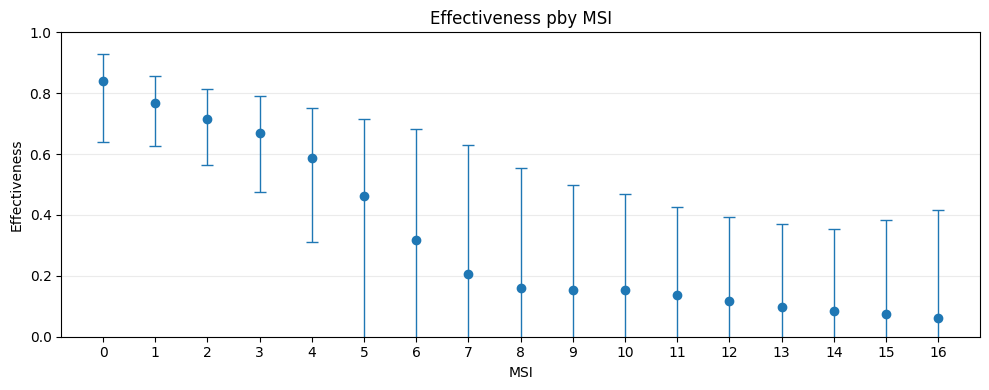

,MSI,Effectiveness,p_value,VE,VE_95_low,VE_95_up
0,0,"0.84 [0.64, 0.93]",<0.001,0.839748,0.640182,0.928629
1,1,"0.77 [0.63, 0.86]",<0.001,0.767926,0.627415,0.855448
2,2,"0.72 [0.56, 0.81]",<0.001,0.716023,0.564861,0.814674
3,3,"0.67 [0.48, 0.79]",<0.001,0.667939,0.475716,0.789686
4,4,"0.59 [0.31, 0.75]",<0.001,0.587217,0.312663,0.752102
5,5,"0.46 [-0.01, 0.71]",0.05,0.462676,-0.009704,0.714057
6,6,"0.32 [-0.47, 0.68]",0.33,0.316852,-0.466081,0.681674
7,7,"0.21 [-0.70, 0.63]",0.55,0.205696,-0.700852,0.629057
8,8,"0.16 [-0.59, 0.56]",0.59,0.158892,-0.590376,0.555160
9,9,"0.15 [-0.43, 0.50]",0.54,0.152939,-0.433873,0.499598


In [236]:
plot_df = ve_df[['MSI','Effectiveness'] + ve_df.columns[1:5].to_list()].sort_values("VE",ascending= False)

# --- Plot ---
x = np.arange(len(plot_df))
y = plot_df["VE"].to_numpy()
yerr_low = y - plot_df["VE_95_low"].to_numpy()
yerr_up  = plot_df["VE_95_up"].to_numpy() - y
yerr = np.vstack([yerr_low, yerr_up])

fig, ax = plt.subplots(figsize=(10, 4))

ax.errorbar(
    x, y,
    yerr=yerr,
    fmt="o",
    capsize=4,
    linewidth=1
)

# opcional: unir puntos
# ax.plot(x, y)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["MSI"].tolist(), rotation=0)
ax.set_xlabel("MSI")
ax.set_ylabel("Effectiveness")
ax.set_title("Effectiveness pby MSI")
ax.grid(alpha=0.25, axis="y")

# Si quieres fijar el rango 0-1 (típico para efectividad)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(plot_df)


In [225]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac']  # 

df_tv = df_cox_vrs_tramos_2year_mod_2.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_cases,
    df_case=df_control,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement=True
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched_repl = df_tv.merge(match_map, on="RUN", how="inner").copy()

event_col = "event_vrs"     # or "event_upc"
strata_col = "Group"      # <-- CHANGE THIS to your matched set id column

df_spline = df_tv_matched_repl.copy()

K = 17
month_cols = [f"inm_mayor_{k}_meses" for k in range(K)]

M = df_spline[month_cols].fillna(0).astype(int).to_numpy()
has_month = M.sum(axis=1) > 0

k = (M * np.arange(K)).sum(axis=1).astype(float)
k[~has_month] = 0.0

# optional: use midpoints to avoid “knot at integers” feel (0.5, 1.5, ...)
df_spline["t_since_imm_m"] = k + 0.5

from sklearn.preprocessing import SplineTransformer
from scipy.stats import norm

n_knots = 6
degree = 3  # cubic

st = SplineTransformer(n_knots=n_knots, degree=degree, include_bias=False)

imm_mask = df_spline["inmunizado"].fillna(0).astype(int).to_numpy() == 1
st.fit(df_spline.loc[imm_mask, ["t_since_imm_m"]])

B = st.transform(df_spline[["t_since_imm_m"]])  # basis for all rows

# Add interaction columns: inmunizado * spline_j(t)
imm = df_spline["inmunizado"].fillna(0).astype(float).to_numpy()
for j in range(B.shape[1]):
    df_spline[f"imm_spl_{j}"] = imm * B[:, j]
    
spline_cols = [c for c in df_spline.columns if c.startswith("imm_spl_")]

# Minimal required columns:
base_cols = ["RUN", "start", "stop", event_col, strata_col]

X_cols = base_cols + spline_cols

ctv = CoxTimeVaryingFitter(penalizer=0.001)  # penalizer=0.01; small ridge often helps with spline stability
ctv.fit(
    df_spline[X_cols],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col=event_col,
    strata=[strata_col],
    show_progress=True
)

display(printSummary(ctv))


spline_cols = [c for c in ctv.params_.index if c.startswith("imm_spl_")]

# Rebuild variance matrix with proper labels (works even if lifelines returned RangeIndex)
V = ctv.variance_matrix_
V = pd.DataFrame(np.asarray(V), index=ctv.params_.index, columns=ctv.params_.index)

Sigma = V.loc[spline_cols, spline_cols].to_numpy()  # (J,J)
beta  = ctv.params_.loc[spline_cols].to_numpy()     # (J,)

months = np.arange(0, 17) + 0.5
B_grid = st.transform(months.reshape(-1, 1))  # (17, J)

logHR = B_grid @ beta

# Var(logHR_t) = b_t' Sigma b_t
var_logHR = np.einsum("ij,jk,ik->i", B_grid, Sigma, B_grid)
se_logHR = np.sqrt(var_logHR)

zcrit = norm.ppf(0.975)
logHR_lo = logHR - zcrit * se_logHR
logHR_hi = logHR + zcrit * se_logHR

HR = np.exp(logHR)
HR_lo = np.exp(logHR_lo)
HR_hi = np.exp(logHR_hi)

VE = 1 - HR
VE_lo = 1 - HR_hi   # flip because VE = 1 - HR
VE_hi = 1 - HR_lo

# Pointwise p-value at each month: H0: logHR(t)=0  (HR=1, VE=0)
z_month = logHR / se_logHR
p_month = 2 * (1 - norm.cdf(np.abs(z_month)))

ve_df = (pd.DataFrame({
            "MSI": (months - 0.5).astype(int),
            "p_value": np.where(p_month < 0.001, '<0.001', p_month.round(2).astype(str)),
            "VE": VE,
            "VE_95_low": VE_lo,
            "VE_95_up": VE_hi,
            "logHR": logHR,
            "SE_logHR": se_logHR,
            "z_month": z_month
        })
         .assign(Effectiveness = lambda x:(x["VE"].map("{:.2f}".format) + " ["+ x["VE_95_low"].map("{:.2f}".format) + ", " + x["VE_95_up"].map("{:.2f}".format)+ "]"))
         .drop(columns=['VE','VE_95_low','VE_95_up'])
)
ve_df[['MSI','Effectiveness'] + ve_df.columns[1:5].to_list()]


1:1 ['1', '1']
here aaa
Total cases = 270604, Total controls = 11285
Total cases matched is : 266428, Total control matched is : 266428
ratio: 1:1
No matched : 4176
Iteration 1: norm_delta = 2.91e-01, step_size = 0.9500, log_lik = -6181.48656, newton_decrement = 6.30e+02, seconds_since_start = 198.4
Iteration 2: norm_delta = 4.25e-02, step_size = 0.9500, log_lik = -5533.38619, newton_decrement = 1.06e+01, seconds_since_start = 366.5
Iteration 3: norm_delta = 4.04e-03, step_size = 0.9500, log_lik = -5522.61051, newton_decrement = 8.13e-02, seconds_since_start = 529.2
Iteration 4: norm_delta = 2.32e-04, step_size = 1.0000, log_lik = -5522.52923, newton_decrement = 2.36e-04, seconds_since_start = 699.6
Iteration 5: norm_delta = 5.84e-08, step_size = 1.0000, log_lik = -5522.52899, newton_decrement = 1.24e-11, seconds_since_start = 880.2
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
imm_spl_0,0.982976,0.960607,0.992643,0.000000,-4.073110,0.428044,-4.912060,-3.234158
imm_spl_1,0.627459,0.562704,0.682625,0.000000,-0.987408,0.081769,-1.147671,-0.827144
imm_spl_2,0.598760,0.541479,0.648885,0.000000,-0.913195,0.068086,-1.046641,-0.779750
imm_spl_3,-0.176376,-0.447876,0.044213,0.125237,0.162439,0.105950,-0.045220,0.370098
imm_spl_4,-0.217513,-0.404852,-0.055156,0.007034,0.196810,0.073023,0.053689,0.339932
imm_spl_5,-0.191685,-0.356952,-0.046547,0.008131,0.175369,0.066263,0.045496,0.305241
imm_spl_6,-0.010639,-0.200103,0.148913,0.903911,0.010583,0.087667,-0.161240,0.182407


,MSI,Effectiveness,p_value,logHR,SE_logHR,z_month
0,0,"0.77 [0.75, 0.80]",<0.001,-1.489323,0.061969,-24.033408
1,1,"0.67 [0.65, 0.70]",<0.001,-1.122221,0.036478,-30.764626
2,2,"0.60 [0.58, 0.63]",<0.001,-0.926745,0.034977,-26.495586
3,3,"0.54 [0.51, 0.58]",<0.001,-0.780432,0.038442,-20.301767
4,4,"0.44 [0.39, 0.48]",<0.001,-0.576586,0.042768,-13.481826
5,5,"0.28 [0.20, 0.35]",<0.001,-0.325062,0.053223,-6.107508
6,6,"0.08 [-0.04, 0.19]",0.18,-0.087950,0.065246,-1.347985
7,7,"-0.08 [-0.23, 0.05]",0.25,0.075737,0.065839,1.150340
8,8,"-0.17 [-0.31, -0.05]",0.01,0.156769,0.056868,2.756700
9,9,"-0.20 [-0.33, -0.09]",<0.001,0.184232,0.049883,3.693285


In [226]:
df_tv_matched_repl_2 = (df_tv_matched_repl
                   [~(df_tv_matched_repl.RUN.isin(df_tv_matched_repl.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_repl_2['inm_mayor_meses_agg_0_1'] = df_tv_matched_repl_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses']].sum(axis=1)
df_tv_matched_repl_2['inm_mayor_meses_agg_2_3'] = df_tv_matched_repl_2[["inm_mayor_2_meses" ,'inm_mayor_3_meses']].sum(axis=1)
df_tv_matched_repl_2['inm_mayor_meses_agg_4_5'] = df_tv_matched_repl_2[["inm_mayor_4_meses" ,'inm_mayor_5_meses']].sum(axis=1)
df_tv_matched_repl_2['inm_mayor_meses_agg_6_8'] = df_tv_matched_repl_2[["inm_mayor_6_meses" ,'inm_mayor_7_meses','inm_mayor_8_meses']].sum(axis=1)

df_tv_matched_repl_2['inm_mayor_meses_agg_mas_de_8'] = df_tv_matched_repl_2[[f'inm_mayor_{k}_meses' for k in range(9,13)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_1','inm_mayor_meses_agg_2_3','inm_mayor_meses_agg_4_5','inm_mayor_meses_agg_6_8','inm_mayor_meses_agg_mas_de_8'] #inm_mayor_meses_agg_6

ctv.fit(
    df_tv_matched_repl_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 5.10e-01, step_size = 0.9500, log_lik = -4542.19347, newton_decrement = 6.08e+02, seconds_since_start = 163.6
Iteration 2: norm_delta = 5.00e-02, step_size = 0.9500, log_lik = -3924.75780, newton_decrement = 5.37e+00, seconds_since_start = 323.0
Iteration 3: norm_delta = 3.23e-03, step_size = 0.9500, log_lik = -3919.36205, newton_decrement = 2.19e-02, seconds_since_start = 488.0
Iteration 4: norm_delta = 1.74e-04, step_size = 1.0000, log_lik = -3919.34022, newton_decrement = 5.69e-05, seconds_since_start = 658.4
Iteration 5: norm_delta = 9.85e-09, step_size = 1.0000, log_lik = -3919.34016, newton_decrement = 1.83e-13, seconds_since_start = 821.2
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_meses_agg_0_1,0.642800,0.612723,0.670540,0.000000,-1.029459,0.041247,-1.110302,-0.948615
inm_mayor_meses_agg_2_3,0.552439,0.512379,0.589208,0.000000,-0.803942,0.043738,-0.889668,-0.718217
inm_mayor_meses_agg_4_5,0.318268,0.234022,0.393248,0.000000,-0.383118,0.059448,-0.499634,-0.266602
inm_mayor_meses_agg_6_8,-0.413012,-0.685018,-0.184914,0.000119,0.345723,0.089825,0.169670,0.521776
inm_mayor_meses_agg_mas_de_8,-0.933007,-1.154624,-0.734185,0.000000,0.659077,0.055378,0.550538,0.767616


Tablas y figuras reporte_decay

In [ ]:
import pandas as pd
import numpy as np

def _month_range(start, end):
    """
    start, end: strings or Timestamps, e.g. '2023-10-01', '2024-09-01'
    Returns month starts (MS frequency), inclusive.
    """
    return pd.date_range(pd.to_datetime(start), pd.to_datetime(end), freq="MS")

def _month_label(dt):
    month_abbr_en = {
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
    }
    return f"{month_abbr_en[dt.month]}-{dt.strftime('%y')}"

def build_birth_and_immune_tables(df, id_col="RUN", birth_col="fecha_nac", inm_col="fechaInm", max_k=16):
    """
    Construye dos tablas:
      - Oct-2023 ... Sep-2024
      - Oct-2024 ... Sep-2025

    Requisitos en df:
      - fecha_nac (datetime)
      - fechaInm (datetime o NaT)
      - columnas inm_0_meses ... inm_{max_k}_meses (datetime o NaT)
    """

    d = df.copy()

    # Asegurar datetime
    d[birth_col] = pd.to_datetime(d[birth_col], errors="coerce")
    d[inm_col]   = pd.to_datetime(d[inm_col], errors="coerce")

    for k in range(max_k + 1):
        col = f"inm_{k}_meses"
        if col in d.columns:
            d[col] = pd.to_datetime(d[col], errors="coerce")
        else:
            raise ValueError(f"Falta columna requerida: {col}")

    # Meses de las 2 tablas
    months_1 = _month_range("2023-10-01", "2024-09-01")
    months_2 = _month_range("2024-10-01", "2025-09-01")

    def _build_one_table(months):
        # Diccionario para armar columnas
        data_cols = {}

        for m_start in months:
            m_end = m_start + pd.offsets.MonthBegin(1)  # inicio del mes siguiente
            colname = _month_label(m_start)

            # -------------------------
            # 1) Born (Immunized / Non-immunized)
            # -------------------------
            born_mask = (d[birth_col] >= m_start) & (d[birth_col] < m_end)

            born_total = int(born_mask.sum())
            born_imm   = int((born_mask & d[inm_col].notna()).sum())
            born_non   = int((born_mask & d[inm_col].isna()).sum())
            
            born_imm_perc = round(born_imm*100/born_total,2)
            born_non_perc = round(born_non*100/born_total,2)

            # Texto compacto como pediste
            # born_text = f"{born_total} ({born_imm}/{born_non})"
            born_text = f"{born_total} ({born_non_perc}%)"

            # -------------------------
            # 2) Months being immune at start of month
            #    "i months and not i+1 months"
            # -------------------------
            col_values = {"Born (Non-imm%)": born_text}

            for i in range(max_k + 1):
                col_i = f"inm_{i}_meses"

                # Cumple ">= i meses al inicio del mes" equiv. a inm_i <= m_start
                has_i = d[col_i].notna() & (d[col_i] <= m_start)

                if i < max_k:
                    col_ip1 = f"inm_{i+1}_meses"
                    has_ip1 = d[col_ip1].notna() & (d[col_ip1] <= m_start)
                    mask_i_exact = has_i & (~has_ip1)
                else:
                    # Último bin = 16+ meses (porque no existe inm_17_meses)
                    mask_i_exact = has_i

                col_values[f"Months being immune = {i}"] = int(mask_i_exact.sum())

            data_cols[colname] = col_values

        # DataFrame final
        out = pd.DataFrame(data_cols)

        # Orden filas
        row_order = ["Born (Non-imm%)"] + [f"Months being immune = {i}" for i in range(max_k + 1)]
        out = out.loc[row_order]

        return out

    table_2023_2024 = _build_one_table(months_1)
    table_2024_2025 = _build_one_table(months_2)

    return table_2023_2024, table_2024_2025

In [429]:
tabla_23_24, tabla_24_25 = build_birth_and_immune_tables(df, max_k=16)

display(tabla_23_24)
display(tabla_24_25)

,Oct-23,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24
Born (Non-imm%),13397 (14.35%),12825 (10.81%),13132 (7.82%),13919 (7.23%),12747 (6.56%),13554 (5.64%),13292 (1.99%),12945 (1.72%),12111 (1.87%),12438 (2.03%),12328 (2.39%),12028 (2.7%)
Months being immune = 0,0,0,0,0,0,0,1647,52849,35194,17826,13931,12358
Months being immune = 1,0,0,0,0,0,0,0,1647,52849,35194,17826,13931
Months being immune = 2,0,0,0,0,0,0,0,0,1647,52849,35194,17826
Months being immune = 3,0,0,0,0,0,0,0,0,0,1647,52849,35194
Months being immune = 4,0,0,0,0,0,0,0,0,0,0,1647,52849
Months being immune = 5,0,0,0,0,0,0,0,0,0,0,0,1647
Months being immune = 6,0,0,0,0,0,0,0,0,0,0,0,0
Months being immune = 7,0,0,0,0,0,0,0,0,0,0,0,0
Months being immune = 8,0,0,0,0,0,0,0,0,0,0,0,0


,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25
Born (Non-imm%),12123 (1.11%),11432 (4.43%),11925 (4.91%),12590 (3.95%),11269 (3.2%),12344 (1.09%),12303 (1.56%),12208 (1.41%),11298 (1.52%),11268 (1.42%),10960 (2.06%),10675 (3.67%)
Months being immune = 0,12050,10950,2835,80,6,448,34868,26375,15592,12699,11861,10964
Months being immune = 1,12358,12050,10950,2835,80,6,448,34868,26375,15592,12699,11861
Months being immune = 2,13931,12358,12050,10950,2835,80,6,448,34868,26375,15592,12699
Months being immune = 3,17826,13931,12358,12050,10950,2835,80,6,448,34868,26375,15592
Months being immune = 4,35194,17826,13931,12358,12050,10950,2835,80,6,448,34868,26375
Months being immune = 5,52849,35194,17826,13931,12358,12050,10950,2835,80,6,448,34868
Months being immune = 6,1647,52849,35194,17826,13931,12358,12050,10950,2835,80,6,448
Months being immune = 7,0,1647,52849,35194,17826,13931,12358,12050,10950,2835,80,6
Months being immune = 8,0,0,1647,52849,35194,17826,13931,12358,12050,10950,2835,80


In [430]:
tabla_23_24.to_excel(path_data/'tabla_1_decay_report.xlsx')
tabla_24_25.to_excel(path_data/'tabla_2_decay_report.xlsx')

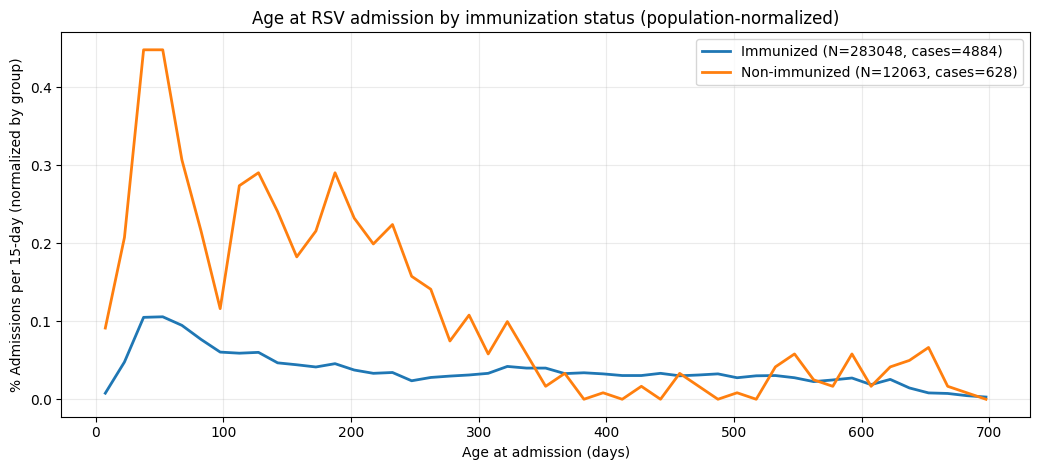

In [443]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df: 1 fila por infante, con fecha_nac, fechaIng_vrs, fechaInm (NaT si nunca), o tu columna inmunizado (0/1)
dfp = df.copy()

# --- define "ever immunized" ---
# si ya tienes dfp["inmunizado"] 0/1, úsalo directamente:
if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)

# --- age at admission (days) solo para quienes tienen ingreso VRS ---
dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days

# sacar edades negativas o absurdas
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 365*2)]  # ajusta si quieres

# --- denominadores poblacionales (para normalizar a la población de cada grupo) ---
N_imm = int((dfp["inmunizado"] == 1).sum())
N_no  = int((dfp["inmunizado"] == 0).sum())

# --- construir histogramas normalizados a población: "casos por bin / población del grupo" ---
bin_width = 15  # días por bin (semanal). Cambia a 14/30 si quieres.
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)

ages_imm = df_evt.loc[df_evt["inmunizado"] == 1, "age_at_adm_days"].to_numpy()
ages_no  = df_evt.loc[df_evt["inmunizado"] == 0, "age_at_adm_days"].to_numpy()

h_imm, _ = np.histogram(ages_imm, bins=bins)
h_no,  _ = np.histogram(ages_no,  bins=bins)

# tasa por bin (proporción de la población que tuvo admisión en ese bin)
rate_imm = h_imm*100 / N_imm if N_imm > 0 else np.zeros_like(h_imm, dtype=float)
rate_no  = h_no*100  / N_no  if N_no  > 0 else np.zeros_like(h_no, dtype=float)

# eje x = centro del bin
x = (bins[:-1] + bins[1:]) / 2

# --- plot ---
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.plot(x, rate_imm, linewidth=2, label=f"Immunized (N={N_imm}, cases={len(ages_imm)})")
ax.plot(x, rate_no,  linewidth=2, label=f"Non-immunized (N={N_no}, cases={len(ages_no)})")

ax.set_xlabel("Age at admission (days)")
ax.set_ylabel(f"% Admissions per {bin_width}-day (normalized by group)")
ax.set_title("Age at RSV admission by immunization status (population-normalized)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

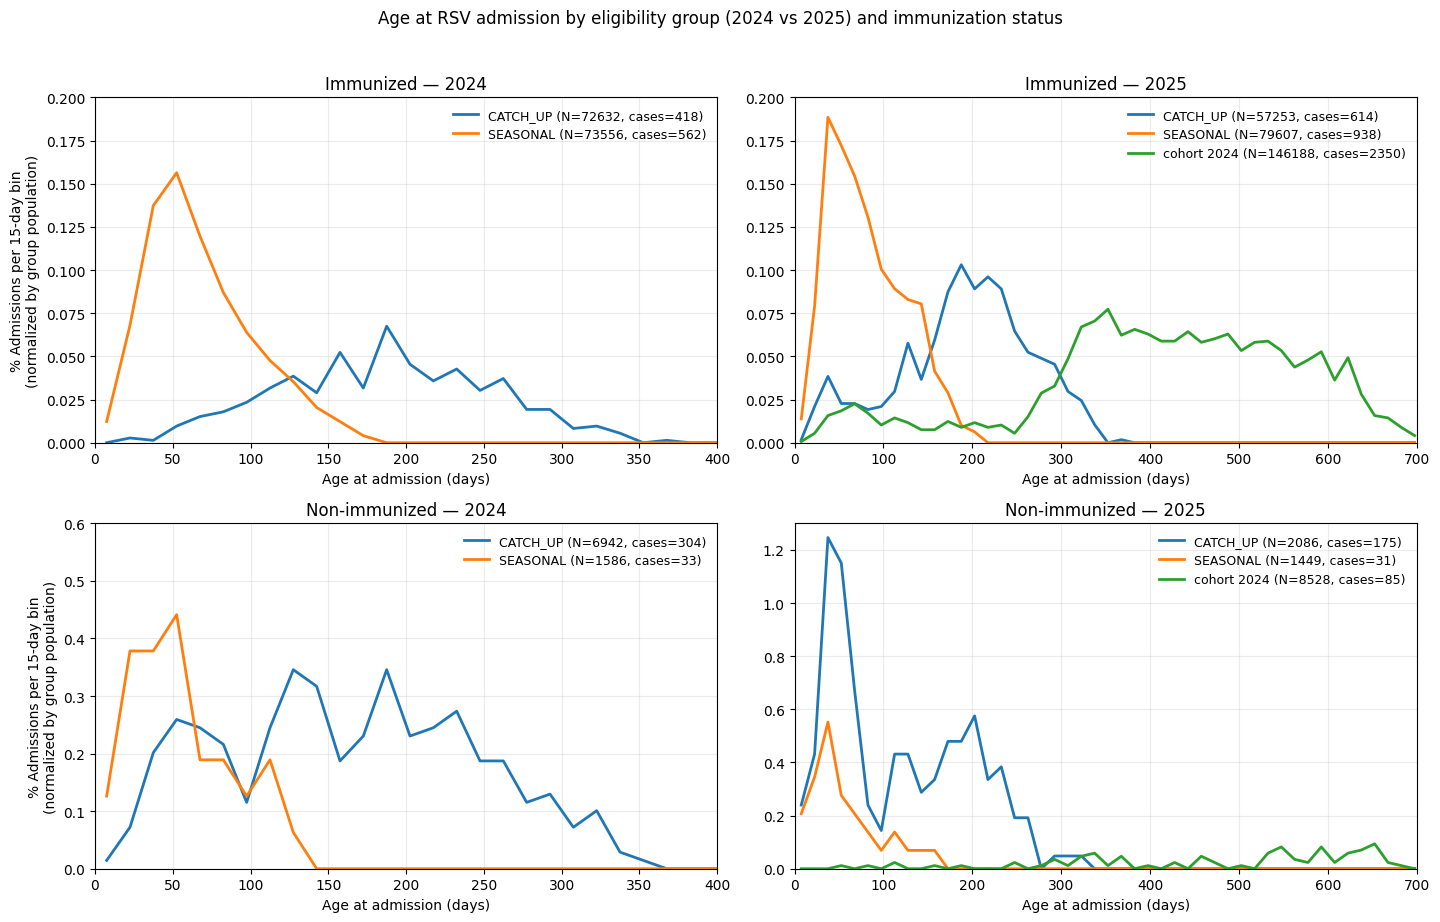

In [473]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfp = df.copy()

dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)
else:
    dfp["inmunizado"] = dfp["inmunizado"].astype(int)

def clean_eleg(s):
    s = s.astype(str).str.strip().str.upper()
    s = s.replace({
        "CATCHUP": "CATCH_UP",
        "CATCH UP": "CATCH_UP",
        "SEASONAL": "SEASONAL",
        "NO_ELEGIBLE": "NO_ELEGIBLE",
        "NO_ELEGIBLE_2024": "NO_ELEGIBLE_2024",
        "NO_ELEGIBLE_2025": "NO_ELEGIBLE_2025",
        "NAN": np.nan,
        "NONE": np.nan
    })
    return s

dfp["eleg_2024"] = clean_eleg(dfp["eleg_2024"])
dfp["eleg_2025"] = clean_eleg(dfp["eleg_2025"])

# Cases only for age-at-admission (sin filtro temporal aún)
df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 700)].copy()

bin_width = 15
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)
x = (bins[:-1] + bins[1:]) / 2

# Cortes de tiempo
cut_2024_start = pd.Timestamp("2023-10-01")
cut_2024_end   = pd.Timestamp("2024-10-01")  # exclusivo (hasta Sep-24 inclusive)
cut_post_2024  = pd.Timestamp("2024-10-01")  # >= Oct-24

mask_evt_2024 = (df_evt["fechaIng_vrs"] >= cut_2024_start) & (df_evt["fechaIng_vrs"] < cut_2024_end)
mask_evt_post = (df_evt["fechaIng_vrs"] >= cut_post_2024)

def rate_curve(inm_val, group_col, group_val, mask_evt):
    # denominator: all infants in that inmunizado x group_val (population)
    N = int(dfp.loc[(dfp["inmunizado"] == inm_val) & (dfp[group_col] == group_val), "RUN"].nunique())

    sub = df_evt.loc[
        mask_evt
        & (df_evt["inmunizado"] == inm_val)
        & (df_evt[group_col] == group_val),
        "age_at_adm_days"
    ].to_numpy()

    h, _ = np.histogram(sub, bins=bins)
    rate = h*100 / N if N > 0 else np.zeros_like(h, dtype=float)
    return rate, N, len(sub)

fig, axes = plt.subplots(2, 2, figsize=(14.5, 9), sharex=False, sharey=False)

groups_24 = ["CATCH_UP", "SEASONAL"]
groups_25 = ["CATCH_UP", "SEASONAL", "NO_ELEGIBLE_2025"]
label_map_25 = {"NO_ELEGIBLE_2025": "cohort 2024"}

panels = [
    # row, col, inm_val, group_col, groups, title, mask_evt
    (0, 0, 1, "eleg_2024", groups_24, "Immunized — 2024",     mask_evt_2024),
    (1, 0, 0, "eleg_2024", groups_24, "Non-immunized — 2024", mask_evt_2024),

    # Para panel 2025: usar eventos post Sep-24 (>= Oct-24)
    (0, 1, 1, "eleg_2025", groups_25, "Immunized — 2025",     mask_evt_post),
    (1, 1, 0, "eleg_2025", groups_25, "Non-immunized — 2025", mask_evt_post),
]

for r, c, inm_val, gcol, groups, title, mask_evt in panels:
    ax = axes[r, c]
    for g in groups:
        # regla extra explícita (por si quieres que SOLO "cohort 2024" use post-2024, y las otras no):
        # if (gcol == "eleg_2025") and (g == "NO_ELEGIBLE_2025"):
        #     mask_use = mask_evt_post
        # else:
        #     mask_use = mask_evt
        mask_use = mask_evt  # como pediste, 2025 usa post Sep-24

        rate, N, n_cases = rate_curve(inm_val, gcol, g, mask_use)
        g_lab = label_map_25.get(g, g)
        ax.plot(x, rate, linewidth=2, label=f"{g_lab} (N={N}, cases={n_cases})")

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Age at admission (days)")
    ax.legend(fontsize=9, frameon=False, loc="upper right")

axes[0, 0].set_ylabel(f"% Admissions per {bin_width}-day bin\n(normalized by group population)")
axes[1, 0].set_ylabel(f"% Admissions per {bin_width}-day bin\n(normalized by group population)")

axes[0, 0].set_ylim(0, 0.2)
axes[0, 1].set_ylim(0, 0.2)
axes[1, 0].set_ylim(0, 0.6)
axes[1, 1].set_ylim(0, 1.3)

axes[0, 0].set_xlim(0, 400)
axes[1, 0].set_xlim(0, 400)

# 2025 panels (col 1)
axes[0, 1].set_xlim(0, 700)
axes[1, 1].set_xlim(0, 700)

fig.suptitle("Age at RSV admission by eligibility group (2024 vs 2025) and immunization status", y=1.02)
plt.tight_layout()
plt.show()